## Dynamic Method with 2018 CTD Data From RVIB Palmer in Terra Nova Bay 

TO-DO: 


- Assess temporal variability in potential density. Make time series plots of potential density vs. time at different depth levels (e.g. 0m, 25m, 75m, 100m, etc…)

- Get estimates of time difference between cast pairs and try to use this to get an error estimate associated with temporal variability (not too sure how to do this yet) 

- Do a monte carlo error analysis on density to assess error with density measurements (likely to be small)

- Also assess errors on spatial variability (not too sure how to do this yet either)



In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patches as mpatches
import gsw
import scipy
import os
import mixsea as mx
import cmocean
 
from scipy.signal import welch, csd
import pandas as pd
import geopandas as gpd
from matplotlib import gridspec

In [2]:
%matplotlib widget 

### Functions 

In [3]:
def TS_template(ax1):
    """ 
    """
    # Create figure
    # fig = plt.figure(figsize=(10, 6),constrained_layout=True)
    # # Top left square
    # ax1 = plt.subplot(1,1,1)

    mint=-2.3
    maxt=-1.4
    mins=34.4
    maxs=35

    tempL=np.linspace(mint,maxt)
    salL=np.linspace(mins,maxs)
    Tg, Sg = np.meshgrid(tempL,salL)

    lon = 165
    lat = -75.0112
    p = 1093
    SA = gsw.SA_from_SP(Sg, p, lon, lat)
    CT = gsw.CT_from_pt(SA, Tg)
    # rho = gsw.rho(SA, Tg, 0)
    # sigma_theta = rho - 1000

    # CALCULATE DENSITY (METHOD 2)
    sigma_theta = gsw.sigma0(SA, CT)

    t_freezing1100 = gsw.t_freezing(gsw.SA_from_SP(salL, 0, lon, lat), p=0, saturation_fraction=0)
    plt.plot(salL, t_freezing1100, 'k--', label='Freezing Line at 0 dbar')

    cs = ax1.contour(Sg, Tg, sigma_theta, colors='k', zorder=1, alpha=0.7, levels=4)
    cl=plt.clabel(cs,fontsize=10,inline=True,manual=[(34.45,-2.2),(34.55,-2.05),(34.75,-1.75)])

In [4]:
def tw_geo_vel(cast1,cast2,int_from_top=False):
    """ 
    """

    # define constants 
    g = 9.81
    rho0 = 1028

    # swap pressure with depth dimension 
    cast1_depth = cast1.swap_dims({'pressure':'depth'})
    cast2_depth = cast2.swap_dims({'pressure':'depth'})

    # define common depth grid 
    d_ref = min(cast1_depth.depth[-1],cast2_depth.depth[-1])
    d_grid = np.arange(0,(d_ref + 1),1)

    # interpolate onto new depth grid 
    cast1_depth_interp = cast1_depth.interp(depth=d_grid)
    cast2_depth_interp = cast2_depth.interp(depth=d_grid)

    # calculate dx - distance between stations 
    dx = gsw.distance([cast1.lon, cast2.lon], [cast1.lat, cast2.lat])[0]

    # calculate coriolis 
    f = gsw.f(0.5 * (cast1.lat + cast2.lat))
    
    # calculate drho_dx 
    # Calculation assumes x positive in east direction
    drho_dx = (cast1_depth_interp.Potential_Density - cast2_depth_interp.Potential_Density)/dx

    # estimate shear from thermal wind equation 
    # note that minus sign has been dropped - this is what aligned with python function dyn height
    shear = (g / (f * rho0)) * drho_dx

    # integrate to get geostrophic velocity 
    if int_from_top == True:
        v_tw = scipy.integrate.cumulative_trapezoid(shear.dropna(dim='depth'),shear.dropna(dim='depth').depth,initial=0)
    elif int_from_top == False:
        v_tw = scipy.integrate.cumulative_trapezoid(shear.dropna(dim='depth')[::-1], x=shear.dropna(dim='depth').depth[::-1], initial=0)[::-1]

    return cast1_depth, cast2_depth, cast1_depth_interp, cast2_depth_interp, dx, drho_dx, shear, v_tw
    

In [5]:
def dyn_height_geo_vel(cast1,cast2):
    """ 
    """
    # define last pressure entry - assuming max pressure is last entry
    p1 = cast1.pressure[-1].values
    p2 = cast2.pressure[-1].values

    # define reference pressure as the minimum max pressure between casts 
    p_ref = int(min(p1,p2))

    # calculate dynamic height 
    dyn1 = gsw.geo_strf_dyn_height(cast1.Absolute_Salinity, cast1.Conservative_Temperature, cast1.pressure, p_ref=p_ref)
    dyn2 = gsw.geo_strf_dyn_height(cast2.Absolute_Salinity, cast2.Conservative_Temperature, cast2.pressure, p_ref=p_ref)

    # add dynamic height to dataset 

    cast1['dyn'] = ('pressure',dyn1)
    cast2['dyn'] = ('pressure', dyn2)

    # define pressure grid to interpolate onto 
    p_grid = np.arange(0,(p_ref+1),1)

    # interpolate data onto pressure grid defined above 
    cast1_interp = cast1.interp(pressure=p_grid,method='linear')
    cast2_interp = cast2.interp(pressure=p_grid,method='linear')

    # calculate dx - distance between stations 
    dx = gsw.distance([cast1.lon, cast2.lon], [cast1.lat, cast2.lat])[0]

    # calculate coriolis 
    f = gsw.f(0.5 * (cast1.lat + cast2.lat))

    # estimate geostrophic velocity 
    v_geo = (cast2_interp.dyn - cast1_interp.dyn)/(f*dx)

    return cast1_interp, cast2_interp, v_geo 

In [18]:
# make into a function 
def TNB_study_site():
    """
    """
    # step 2: 
    proj = ccrs.SouthPolarStereo(central_longitude=165)

    fig, ax = plt.subplots(subplot_kw={"projection": proj})

    ax.set_extent([162, 170, -75.75, -74.25], crs=ccrs.PlateCarree())

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--'
    )

    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'weight': 'bold'}
    gl.ylabel_style = {'size': 10, 'weight': 'bold'}
    # set latitude tick marks 
    gl.ylocator = plt.FixedLocator([-75.6,-75, -74.4])

    depth = -bath.sel(lat=slice(lat_min,lat_max),lon=slice(lon_min,lon_max))['elevation']

    levels = [700,1000, 1100, 1200]

    contours = ax.contour(
        depth['lon'],
        depth['lat'],
        depth,
        levels=levels,
        colors='black',
        linewidths=0.7,
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    ax.clabel(contours, fmt='%d m', fontsize=8, inline=True, inline_spacing=1)

    ax.add_geometries(
        ice_clip.geometry,
        crs=ccrs.PlateCarree(),
        facecolor='lightgrey',
        edgecolor='k',
        linewidth=0.3,
        zorder=3
    )

    ax.add_geometries(
        land_clip.geometry,
        crs=ccrs.PlateCarree(),
        facecolor='grey',
        edgecolor='k',
        linewidth=0.3,
        zorder=3
    )
    return fig, ax


In [7]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})


def plot_tw_geo_vel_summary(
    cast1,
    cast2,
    bath,
    ice_clip,
    land_clip,
    Rd_casts,
    ditd_lon, ditd_lat,
    tnbd_lon, tnbd_lat,
    D_lon, D_lat,
    lat_min, lat_max,
    lon_min, lon_max,
    int_from_top=False,
    save_path=None,
    dpi=150,
):
    """
    Five-panel summary figure for thermal wind geostrophic velocity analysis.

    Layout
    ------
    [ empty ]  [ MAP (top center) ]  [ empty ]
    [ CTD raw ] [ CTD interp ]  [ density grad ] [ geo vel ]
      (bottom row: 2x2 grid)

    Parameters
    ----------
    cast1, cast2    : xarray Datasets with CTD data
    bath            : xarray Dataset with 'elevation' variable on lat/lon
    ice_clip        : GeoDataFrame for ice shelf geometry
    land_clip       : GeoDataFrame for land geometry
    Rd_casts        : dict  {station_number: Rd_value_in_meters}
    ditd_lon/lat    : float  — DITD mooring location
    tnbd_lon/lat    : float  — TNBD mooring location
    D_lon/D_lat     : float  — D mooring location
    lat_min/max     : float  — bounding box for bathymetry extraction
    lon_min/max     : float  — bounding box for bathymetry extraction
    int_from_top    : bool   — integration direction for tw_geo_vel
    save_path       : str or None  — if given, saves figure to this path
    dpi             : int    — resolution for saved figure

    Returns
    -------
    fig : matplotlib Figure
    axes : dict with keys 'map', 'ctd_raw', 'ctd_interp', 'drho', 'vel'
    """

    # ------------------------------------------------------------------ #
    #  Run geostrophic velocity calculation                                #
    # ------------------------------------------------------------------ #
    (cast1_depth, cast2_depth,
     cast1_depth_interp, cast2_depth_interp,
     dx, drho_dx, shear, v_tw) = tw_geo_vel(cast1, cast2, int_from_top=False)

    shear_sfc = tw_geo_vel(cast1, cast2, int_from_top=True)[6]
    v_tw_sfc  = tw_geo_vel(cast1, cast2, int_from_top=True)[7]

    # ------------------------------------------------------------------ #
    #  Build figure layout                                                 #
    # ------------------------------------------------------------------ #
    fig = plt.figure(figsize=(10, 13))  # close to letter page with margins

    outer = gridspec.GridSpec(
        2, 1,
        figure=fig,
        height_ratios=[1.0, 2.0],   # map compact, profiles get 2/3 of page
        hspace=0.4,
    )

    top_gs = gridspec.GridSpecFromSubplotSpec(
        1, 3,
        subplot_spec=outer[0],
        width_ratios=[0.2, 1, 0.2],
    )

    bot_gs = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer[1],
        hspace=0.5,
        wspace=0.4,
    )

    # ------------------------------------------------------------------ #
    #  Panel 1 — Map (top centre)                                         #
    # ------------------------------------------------------------------ #
    proj = ccrs.SouthPolarStereo(central_longitude=165)
    ax_map = fig.add_subplot(top_gs[0, 1], projection=proj)

    ax_map.set_extent([162, 170, -75.75, -74.25], crs=ccrs.PlateCarree())

    gl = ax_map.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.5,
        linestyle='--',
    )
    gl.top_labels    = False
    gl.right_labels  = False
    gl.xlabel_style  = {'size': 9, 'weight': 'bold'}
    gl.ylabel_style  = {'size': 9, 'weight': 'bold'}
    gl.ylocator      = plt.FixedLocator([-75.6, -75, -74.4])

    # Bathymetry contour
    depth = -bath.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))['elevation']
    contours = ax_map.contour(
        depth['lon'], depth['lat'], depth,
        levels=[400, 600, 800, 1000, 1100],
        colors='black', linewidths=0.7,
        transform=ccrs.PlateCarree(), zorder=2,
    )
    ax_map.clabel(contours, fmt='%d m', fontsize=7, inline=True, inline_spacing=1)

    # Ice & land
    ax_map.add_geometries(
        ice_clip.geometry, crs=ccrs.PlateCarree(),
        facecolor='lightgrey', edgecolor='k', linewidth=0.3, zorder=3,
    )
    ax_map.add_geometries(
        land_clip.geometry, crs=ccrs.PlateCarree(),
        facecolor='grey', edgecolor='k', linewidth=0.3, zorder=3,
    )

    # CTD cast locations
    for cast, color in [(cast1, 'tab:blue'), (cast2, 'tab:blue')]:
        ax_map.scatter(
            cast.lon, cast.lat,
            transform=ccrs.PlateCarree(), zorder=11, color=color, s=40,
        )
        ax_map.text(
            cast.lon.item(), cast.lat.item(),
            str(cast.station.item()),
            transform=ccrs.PlateCarree(),
            fontsize=8, ha='center', va='bottom', zorder=11, weight='bold',
        )

    # Mooring locations
    for mlon, mlat in [(ditd_lon, ditd_lat), (tnbd_lon, tnbd_lat), (D_lon, D_lat)]:
        ax_map.scatter(
            mlon, mlat,
            transform=ccrs.PlateCarree(), zorder=10, color='r', s=40,
        )

    # Title with cast metadata
    st1, st2    = cast1.station.item(), cast2.station.item()
    date1, date2 = cast1.date.item(), cast2.date.item()
    Rd1, Rd2    = Rd_casts[st1], Rd_casts[st2]
    ax_map.set_title(
        f'Cast {st1} ({date1})  Rd={Rd1/1000:.1f} km\n'
        f'Cast {st2} ({date2})  Rd={Rd2/1000:.1f} km   '
        f'dx={dx/1000:.1f} km',
        fontsize=10,
    )

    # ------------------------------------------------------------------ #
    #  Panel 2 — CTD raw profiles  (bottom left)                          #
    # ------------------------------------------------------------------ #
    ax_ctd = fig.add_subplot(bot_gs[0, 0])
    ax_ctd.plot(cast1_depth.Potential_Density, cast1_depth.depth,
                label=f'Stn {cast1_depth.station.values}')
    ax_ctd.plot(cast2_depth.Potential_Density, cast2_depth.depth,
                label=f'Stn {cast2_depth.station.values}')
    ax_ctd.invert_yaxis()
    ax_ctd.set_ylabel('Depth [m]')
    ax_ctd.set_xlabel('Pot. Density [kg m⁻³]')
    ax_ctd.set_title('CTD Profiles')
    ax_ctd.legend(fontsize=8)

    # ------------------------------------------------------------------ #
    #  Panel 3 — CTD interpolated profiles  (bottom right of top sub-row) #
    # ------------------------------------------------------------------ #
    ax_interp = fig.add_subplot(bot_gs[0, 1])
    ax_interp.plot(cast1_depth_interp.Potential_Density, cast1_depth_interp.depth,
                   label=f'Stn {cast1_depth_interp.station.values}')
    ax_interp.plot(cast2_depth_interp.Potential_Density, cast2_depth_interp.depth,
                   label=f'Stn {cast2_depth_interp.station.values}')
    ax_interp.invert_yaxis()
    ax_interp.set_ylabel('Depth [m]')
    ax_interp.set_xlabel('Pot. Density [kg m⁻³]')
    ax_interp.set_title('CTD Profiles (Interpolated)')
    ax_interp.legend(fontsize=8)

    # ------------------------------------------------------------------ #
    #  Panel 4 — Meridional density gradient  (bottom left of lower row)  #
    # ------------------------------------------------------------------ #
    ax_drho = fig.add_subplot(bot_gs[1, 0])
    ax_drho.plot(drho_dx, drho_dx.depth)
    ax_drho.axvline(0, color='k', linewidth=0.6, linestyle='--')
    ax_drho.invert_yaxis()
    ax_drho.set_ylabel('Depth [m]')
    ax_drho.set_xlabel('Density Gradient [kg m⁻³ m⁻¹]')
    ax_drho.set_title('Density Gradient')

    # ------------------------------------------------------------------ #
    #  Panel 5 — Geostrophic velocity  (bottom right of lower row)        #
    # ------------------------------------------------------------------ #
    ax_vel = fig.add_subplot(bot_gs[1, 1])
    ax_vel.plot(v_tw,     shear.dropna(dim='depth').depth,     label='upward')
    ax_vel.plot(v_tw_sfc, shear_sfc.dropna(dim='depth').depth, label='downward')
    ax_vel.axvline(0, color='k', linewidth=0.6, linestyle='--')
    ax_vel.invert_yaxis()
    ax_vel.set_ylabel('Depth [m]')
    ax_vel.set_xlabel('Geostrophic Velocity [m s⁻¹]')
    ax_vel.set_title('Baroclinic Velocity')
    ax_vel.legend(fontsize=8)

    # ------------------------------------------------------------------ #
    #  Save                                                                #
    # ------------------------------------------------------------------ #
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'Figure saved → {save_path}')

    axes = {
        'map':       ax_map,
        'ctd_raw':   ax_ctd,
        'ctd_interp': ax_interp,
        'drho':      ax_drho,
        'vel':       ax_vel,
    }
    return fig, axes


# ------------------------------------------------------------------ #
#  Example call                                                        #
# ------------------------------------------------------------------ #
# fig, axes = plot_tw_geo_vel_summary(
#     cast1, cast2,
#     bath, ice_clip, land_clip,
#     Rd_casts,
#     ditd_lon, ditd_lat,
#     tnbd_lon, tnbd_lat,
#     D_lon, D_lat,
#     lat_min, lat_max,
#     lon_min, lon_max,
#     int_from_top=False,
#     save_path='tw_geo_vel_summary.png',   # or .pdf / .svg
# )
# plt.show()

### Load Data 

In [8]:
# Mooring location (constant lat/lon)
tnbd_lat = -75.0112
tnbd_lon = 165.5562

ditd_lat = -75.2751
ditd_lon = 164.0625

D_lat = -75.133
D_lon = 164.542

ditn_lat = -75.36083
ditn_lon = 164.7463

p2_lat = -71.4601
p2_lon = 172.3024

p3_lat = -71.9181
p3_lon = 172.9265

ldeo_lat = -74.97
ldeo_lon = 163.96

dits_lat = -75.4886
dits_lon = 163.2042

In [9]:
# # DELL 
bath = xr.open_dataset('/Users/mblan/Documents/research/data/gebco_2024_n-66.2651_s-87.7985_w159.418_e213.2403.nc')


# MAC
# bath = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/gebco_2024_n-66.2651_s-87.7985_w159.418_e213.2403.nc')

In [10]:
# DELL 
gdf = gpd.read_file("/Users/mblan/Documents/research/data/add_coastline_high_res_polygon_v7.2/add_coastline_high_res_polygon_v7.2.shp")

# # MAC
# gdf = gpd.read_file("/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/add_coastline_high_res_polygon_v7.2/add_coastline_high_res_polygon_v7.2.shp")

### TNB Study Site Map 

In [11]:
# make sure it is in lon/lat
if gdf.crs is not None:
    gdf = gdf.to_crs("EPSG:4326")

ice = gdf[gdf["surface"].isin(["ice shelf", "ice tongue"])]
land = gdf[gdf["surface"].isin(["land"])]

from shapely.geometry import box

region = box(162, -75.75, 170, -74.25)
ice_clip = ice.clip(region)
land_clip = land.clip(region)

In [12]:
lat_min = -76
lat_max = -74
lon_min = 162
lon_max = 170

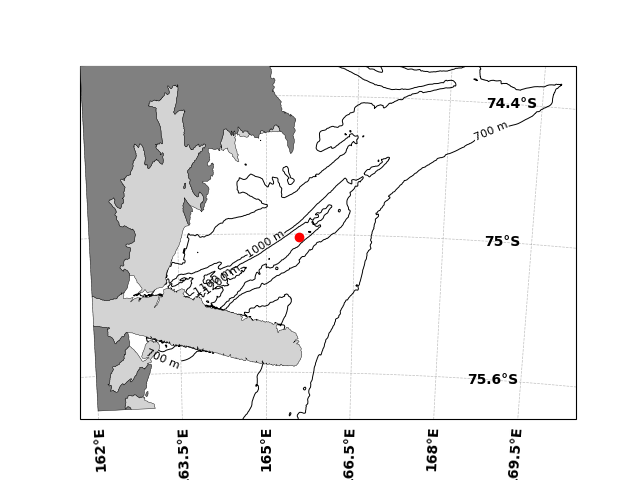

In [23]:
fig, ax = TNB_study_site()
plt.scatter(tnbd_lon,tnbd_lat,color='r',zorder=10,transform=ccrs.PlateCarree())

### CTD data 

#### Load and Format Data 

In [11]:
# Load data - DELL 
df = pd.read_csv("/Users/mblan/Documents/research/data/ctd.csv")

# # load data - MAC 
# df = pd.read_csv('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/ctd_012018_palmer.csv')

# Use station as the only dimension
ds = df.set_index('Station').to_xarray()

In [12]:
# 1. Rename the current dimension to reflect observation number 
ds1 = ds.rename_dims({'Station': 'obs'}).rename_vars({'Station': 'station'})

# 2. Build a sample index within each station
station_vals = ds1['station'].values

sample = np.zeros(len(station_vals), dtype=int)
count = {}

for i, st in enumerate(station_vals):
    sample[i] = count.get(st, 0)
    count[st] = count.get(st, 0) + 1

# 3. Attach sample as a coordinate on obs
ds1 = ds1.assign_coords(sample=('obs', sample))

# 4. Reshape from long -> 2D
ds2 = ds1.set_index(obs=['station', 'sample']).unstack('obs')

In [13]:
# reformat lat / lon to be coordinates 
lat1d = ds2['Latitude'].isel(sample=0)
lon1d = ds2['Longitude'].isel(sample=0)

ds2 = ds2.assign_coords(
    lat=('station', lat1d.values),
    lon=('station', lon1d.values)
)

In [14]:
ds2 = ds2.drop_vars(['Latitude', 'Longitude'])

In [15]:
# select Drygalski Trough region 
ds_sub = ds2.where(
    (ds2.lon > 163) & (ds2.lon < 167) &
    (ds2.lat > -76) & (ds2.lat < -74),
    drop=True
)

Text(0.5, 1.0, 'Map 3: CTD Casts in TNB Drygalski Trough')

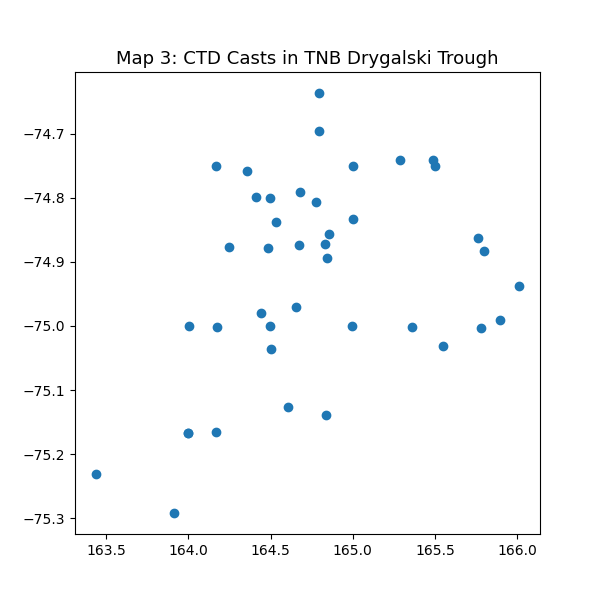

In [16]:
fig = plt.figure(figsize=(6,6))
plt.scatter(ds_sub.lon,ds_sub.lat)
plt.title('Map 3: CTD Casts in TNB Drygalski Trough')

In [17]:
ds_sub['Absolute_Salinity'] = gsw.SA_from_SP(ds_sub.Salinity,ds_sub.Pressure,ds_sub.lon,ds_sub.lat)
# should a reference pressure of zero be used? 
ds_sub['Potential_Temperature'] = gsw.pt_from_t(ds_sub.Absolute_Salinity,ds_sub.Temperature,ds_sub.Pressure,0)
ds_sub['Conservative_Temperature'] = gsw.CT_from_pt(ds_sub.Absolute_Salinity,ds_sub.Potential_Temperature)
ds_sub['Potential_Density'] = gsw.sigma0(ds_sub.Absolute_Salinity,ds_sub.Conservative_Temperature)

In [18]:
casts = {}

for st in ds_sub.station.values:
    cast = ds_sub.sel(station=st).sortby('Pressure')

    mask = (
        np.isfinite(cast.Pressure) &
        np.isfinite(cast.Absolute_Salinity) &
        np.isfinite(cast.Conservative_Temperature)
    )
    cast = cast.isel(sample=mask)

    # remove duplicate pressures
    _, ind = np.unique(cast.Pressure.values, return_index=True)
    cast = cast.isel(sample=np.sort(ind))

    # build a new dataset with pressure as dimension
    cast_clean = xr.Dataset(
        data_vars=dict(
            Temperature=('pressure', cast.Temperature.values),
            Conservative_Temperature=('pressure', cast.Conservative_Temperature.values),
            Salinity=('pressure', cast.Salinity.values),
            Absolute_Salinity=('pressure', cast.Absolute_Salinity.values),
            Potential_Density=('pressure', cast.Potential_Density.values),
            Potential_Temperature=('pressure',cast.Potential_Temperature.values),
            Oxygen=('pressure', cast.Oxygen.values),
            depth=('pressure', cast.Depth.values) if 'Depth' in cast else ('pressure', np.full(len(cast.Pressure), np.nan)),
        ),
        coords=dict(
            pressure=('pressure', cast.Pressure.values),
            station=st,
            lat=float(cast.lat) if 'lat' in cast else np.nan,
            lon=float(cast.lon) if 'lon' in cast else np.nan,
            date=cast.isel(sample=0).ISO_DateTime_UTC.values,
        ),
        attrs=dict(
            date=str(cast.Date.isel(sample=0).values) if 'Date' in cast else ''
        )
    )

    casts[st] = cast_clean

#### Preliminary plots 

In [24]:
ds_sub

<xarray.Dataset> Size: 13MB
Dimensions:                   (station: 41, sample: 1522)
Coordinates:
  * station                   (station) int64 328B 22 23 24 25 ... 77 78 79 80
    lat                       (station) float64 328B -75.0 -75.0 ... -74.86
    lon                       (station) float64 328B 165.4 165.8 ... 164.8 164.9
  * sample                    (sample) int64 12kB 0 1 2 3 ... 1519 1520 1521
Data variables: (12/27)
    Date                      (station, sample) object 499kB '2018-01-09' ......
    Julian_Day                (station, sample) float64 499kB 9.197 ... nan
    ISO_DateTime_UTC          (station, sample) object 499kB '2018-01-09T04:4...
    Pressure                  (station, sample) float64 499kB 1.0 2.0 ... nan
    Depth                     (station, sample) float64 499kB 0.982 ... nan
    Temperature               (station, sample) float64 499kB 0.7381 ... nan
    ...                        ...
    Scans_bin                 (station, sample) float64 499kB 25.0 53.0 ... nan
    Flag                      (station, sample) float64 499kB 0.0 0.0 ... nan
    Absolute_Salinity         (station, sample) float64 499kB 34.73 ... nan
    Potential_Temperature     (station, sample) float64 499kB 0.7381 ... nan
    Conservative_Temperature  (station, sample) float64 499kB 0.7394 ... nan
    Potential_Density         (station, sample) float64 499kB 27.71 ... nan

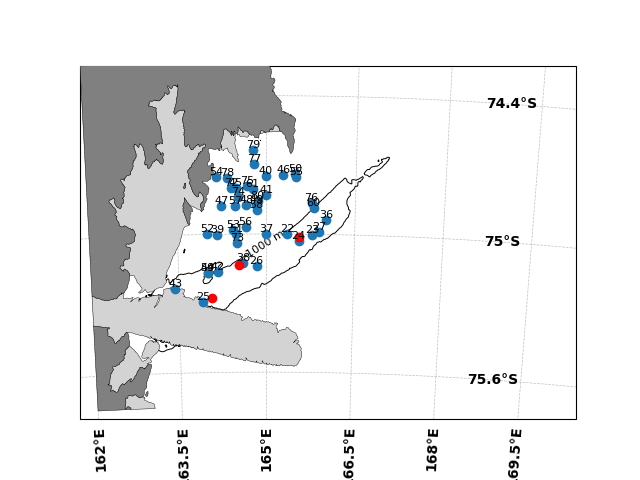

In [25]:
fig, ax = TNB_study_site()

ax.scatter(
    ds_sub.lon,
    ds_sub.lat,
    transform=ccrs.PlateCarree(),
    zorder=10
)
# Add station labels
for i in range(len(ds_sub.station)):
    ax.text(
        ds_sub.lon.isel(station=i).item(),
        ds_sub.lat.isel(station=i).item(),
        str(ds_sub.station.isel(station=i).item()),
        transform=ccrs.PlateCarree(),
        fontsize=8,
        ha='center',
        va='bottom',
        zorder=11
    )


ax.scatter(ditd_lon,ditd_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')
ax.scatter(tnbd_lon,tnbd_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')
ax.scatter(D_lon,D_lat,transform=ccrs.PlateCarree(),
    zorder=10,color='r')

# plt.savefig('Palmer_CTD_studysite.png',dpi=400)

In [27]:
# stations within Drygalski Basin 1000 m bathymetric contour 
stations = [44,59,43,25,42,38,26,22,24,23,27,36,60]

Palmer_ctd_DrygalskiBasin = ds_sub.sel(station=stations)

In [ ]:
# Palmer_ctd_DrygalskiBasin.to_netcdf('Palmer_ctd_DrygalskiBasin.nc')

In [26]:
ds_sub

<xarray.Dataset> Size: 13MB
Dimensions:                   (station: 41, sample: 1522)
Coordinates:
  * station                   (station) int64 328B 22 23 24 25 ... 77 78 79 80
    lat                       (station) float64 328B -75.0 -75.0 ... -74.86
    lon                       (station) float64 328B 165.4 165.8 ... 164.8 164.9
  * sample                    (sample) int64 12kB 0 1 2 3 ... 1519 1520 1521
Data variables: (12/27)
    Date                      (station, sample) object 499kB '2018-01-09' ......
    Julian_Day                (station, sample) float64 499kB 9.197 ... nan
    ISO_DateTime_UTC          (station, sample) object 499kB '2018-01-09T04:4...
    Pressure                  (station, sample) float64 499kB 1.0 2.0 ... nan
    Depth                     (station, sample) float64 499kB 0.982 ... nan
    Temperature               (station, sample) float64 499kB 0.7381 ... nan
    ...                        ...
    Scans_bin                 (station, sample) float64 499kB 25.0 53.0 ... nan
    Flag                      (station, sample) float64 499kB 0.0 0.0 ... nan
    Absolute_Salinity         (station, sample) float64 499kB 34.73 ... nan
    Potential_Temperature     (station, sample) float64 499kB 0.7381 ... nan
    Conservative_Temperature  (station, sample) float64 499kB 0.7394 ... nan
    Potential_Density         (station, sample) float64 499kB 27.71 ... nan

Text(0.5, 0.98, 'Station 76, 2018-02-17')

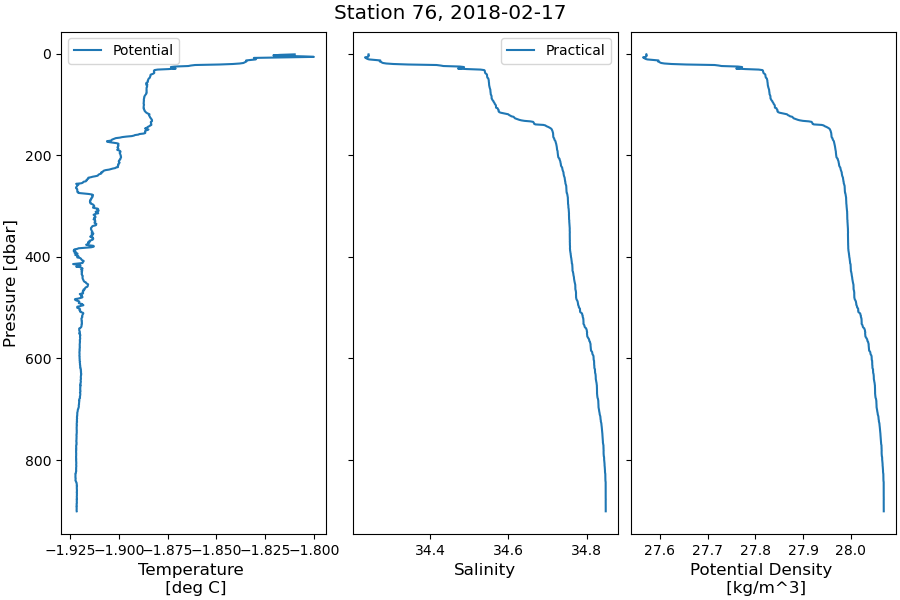

In [23]:
station = 76
ds_st = ds_sub.sel(station=station)

fig, axes = plt.subplots(1, 3, figsize=(9,6), constrained_layout=True, sharey=True)

# 1st panel
axes[0].plot(ds_st.Potential_Temperature, ds_st.Pressure,label='Potential')
# axes[0].plot(ds_st.Temperature, ds_st.Pressure,label='In-Situ')
# axes[0].plot(ds_st.Conservative_Temperature, ds_st.Pressure,label='Conservative')
axes[0].legend()
axes[0].set_xlabel('Temperature \n [deg C]')
axes[0].set_ylabel('Pressure [dbar]')
axes[0].invert_yaxis()

# 2nd panel
# axes[1].plot(ds_st.Absolute_Salinity, ds_st.Pressure,label='Absolute')
axes[1].plot(ds_st.Salinity, ds_st.Pressure,label='Practical')
axes[1].legend()
axes[1].set_xlabel('Salinity')
axes[1].invert_yaxis()

# 3rd panel
axes[2].plot(ds_st.Potential_Density, ds_st.Pressure)
axes[2].set_xlabel('Potential Density \n [kg/m^3]')
axes[2].invert_yaxis()

# Title
st_num = ds_st.station.item()
date = ds_sub.Date.sel(station=station).isel(sample=0).item()

fig.suptitle(f'Station {st_num}, {date}')

In [23]:
# # Calculate N2 and Rd, save as dictionaries keyed by station number 
# N2_casts = {}
# Rd_casts = {}

# for st, cast in casts.items():
#     SA = cast.Absolute_Salinity.values
#     CT = cast.Conservative_Temperature.values
#     p = cast.pressure.values
#     lat = float(cast.lat)
#     lon = float(cast.lon)

#     N2, p_mid = gsw.Nsquared(SA, CT, p, lat=lat)

#     N2_da = xr.DataArray(
#         N2,
#         dims=['p_mid'],
#         coords={
#             'p_mid': p_mid,
#             'station': st,
#             'lat': lat,
#             'lon': lon,
#         },
#         name='N2',
#         attrs={
#             'long_name': 'Brunt-Vaisala frequency squared',
#             'units': 's^-2'
#         }
#     )

#     if 'Date' in cast:
#         date_val = cast.Date.isel(sample=0).item() if 'sample' in cast.Date.dims else cast.Date.item()
#         N2_da = N2_da.assign_coords(date=date_val)

#     N2_casts[st] = N2_da

#     N = np.where(N2 > 0, np.sqrt(N2), np.nan)
#     H = float(cast.depth.max())
#     f = np.abs(gsw.f(lat))

#     Rd = (np.nanmean(N) * H) / f
#     Rd_casts[st] = Rd

#### Calculate N2 and Plot 

In [19]:
# Calculate N2 and Rd, save as dictionaries keyed by station number 
# Here N2 is calculated via adiabatic leveling 
N2_casts = {}
Rd_casts = {}

for st, cast in casts.items():
    S = cast.Salinity.values
    T = cast.Temperature.values
    p = cast.pressure.values
    lat = float(cast.lat)
    lon = float(cast.lon)

    N2 = mx.nsq.adiabatic_leveling(P=p,
                          S=S,
                          T=T,
                          lon=lon,
                          lat=lat,
                          bin_width=20,
                          cap=None)

    N2_da = xr.DataArray(
        N2,
        dims=['p'],
        coords={
            'p': p,
            'station': st,
            'lat': lat,
            'lon': lon,
        },
        name='N2',
        attrs={
            'long_name': 'Brunt-Vaisala frequency squared',
            'units': 's^-2',
            'method': 'mixsea adiabatic leveling'
        }
    )

    if 'Date' in cast:
        date_val = cast.Date.isel(sample=0).item() if 'sample' in cast.Date.dims else cast.Date.item()
        N2_da = N2_da.assign_coords(date=date_val)

    N2_casts[st] = N2_da

    N = np.where(N2 > 0, np.sqrt(N2), np.nan)
    H = float(cast.depth.max())
    f = np.abs(gsw.f(lat))

    Rd = (np.nanmean(N) * H) / f
    Rd_casts[st] = Rd

C:\Users\mblan\AppData\Local\Temp\ipykernel_8264\3983851057.py:44: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
C:\Users\mblan\AppData\Local\Temp\ipykernel_8264\3983851057.py:44: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
C:\Users\mblan\AppData\Local\Temp\ipykernel_8264\3983851057.py:44: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
C:\Users\mblan\AppData\Local\Temp\ipykernel_8264\3983851057.py:44: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
C:\Users\mblan\AppData\Local\Temp\ipykernel_8264\3983851057.py:44: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
C:\Users\mblan\AppData\Local\Temp\ipykernel_8264\3983851057.py:44: RuntimeWarning: invalid value encountered in sqrt
  N = np.where(N2 > 0, np.sqrt(N2), np.nan)
C:\Users\mblan\AppData\Local\Temp\

In [23]:
casts.keys()

dict_keys([np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(76), np.int64(77), np.int64(78), np.int64(79), np.int64(80)])

In [24]:
casts[22]

<xarray.Dataset> Size: 79kB
Dimensions:                   (pressure: 1092)
Coordinates:
  * pressure                  (pressure) float64 9kB 1.0 2.0 ... 1.092e+03
    station                   int64 8B 22
    lat                       float64 8B -75.0
    lon                       float64 8B 165.4
    date                      object 8B '2018-01-09T04:43:04Z'
Data variables:
    Temperature               (pressure) float64 9kB 0.7381 0.734 ... -1.889
    Conservative_Temperature  (pressure) float64 9kB 0.7394 0.7353 ... -1.918
    Salinity                  (pressure) float64 9kB 34.56 34.56 ... 34.85 34.85
    Absolute_Salinity         (pressure) float64 9kB 34.73 34.73 ... 35.02 35.02
    Potential_Density         (pressure) float64 9kB 27.71 27.71 ... 28.07 28.07
    Potential_Temperature     (pressure) float64 9kB 0.7381 0.7339 ... -1.921
    Oxygen                    (pressure) float64 9kB 9.598 9.598 ... 6.693 6.7
    depth                     (pressure) float64 9kB 0.982 1.978 ... 1.078e+03
Attributes:
    date:     2018-01-09

In [41]:
np.sqrt(N2_casts[37])

c:\Users\mblan\miniforge3\envs\ocean\Lib\site-packages\xarray\computation\apply_ufunc.py:820: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


<xarray.DataArray 'N2' (p: 888)> Size: 7kB
array([0.01998432, 0.02235847, 0.02351708, 0.02397941, 0.02427586,
       0.02417821, 0.02386959, 0.02344859, 0.02296577, 0.02246606,
       0.02195587, 0.02169675, 0.02119337, 0.0204269 , 0.01936137,
       0.01794042, 0.01611539, 0.01383542, 0.01282509, 0.01122894,
       0.0087237 , 0.00778997, 0.00696627, 0.00618574, 0.00598656,
       0.00576313, 0.00553617, 0.00531868, 0.00515049, 0.00505695,
       0.00501671, 0.00496538, 0.00489224, 0.00477922, 0.00461754,
       0.00444407, 0.00430351, 0.00418443, 0.0040513 , 0.00389919,
       0.00372554, 0.00354409, 0.00335715, 0.00317887, 0.00303217,
       0.00292756, 0.00283779, 0.00274886, 0.00272718, 0.00271105,
       0.00270846, 0.00271253, 0.00272473, 0.00273134, 0.00272347,
       0.00271267, 0.00269074, 0.00266204, 0.00262907, 0.00259317,
       0.00255941, 0.00251562, 0.00247541, 0.00243686, 0.0023969 ,
       0.00234931, 0.00229325, 0.00224878, 0.00219731, 0.00216106,
       0.00211964, 0.0020644 , 0.00200261, 0.00194632, 0.00189799,
       0.00185955, 0.00182126, 0.001782  , 0.00174535, 0.00171309,
       0.00170616, 0.00171172, 0.00170505, 0.00169266, 0.00166898,
       0.00163593, 0.00160854, 0.00159772, 0.00158719, 0.0015985 ,
       0.00160109, 0.0015966 , 0.00158715, 0.00157201, 0.00155957,
       0.00154912, 0.00153446, 0.00152451, 0.0015282 , 0.00152871,
...
       0.00076279, 0.00080341, 0.00084421, 0.00087119, 0.00089266,
       0.00089545, 0.00089446, 0.00088871, 0.00088573, 0.00087141,
       0.0008517 , 0.00084047, 0.00081722, 0.0007722 , 0.00074378,
       0.00070973, 0.00066919, 0.00063926, 0.00062481, 0.00060532,
       0.0006034 , 0.00062913, 0.00066766, 0.00071932, 0.00076511,
       0.00078963, 0.00080917, 0.00081679, 0.00082107, 0.00082251,
       0.00082787, 0.00082202, 0.00082635, 0.00080545, 0.00077358,
       0.00073122, 0.0006929 , 0.0006313 , 0.00057514, 0.00050156,
       0.00041551, 0.00036112, 0.00030046, 0.00024266, 0.00019469,
       0.00016559, 0.00016336, 0.00011091,        nan,        nan,
              nan,        nan, 0.00014004, 0.00017152, 0.00011825,
       0.00014578, 0.00016679, 0.00017922, 0.00015308, 0.00015601,
       0.00018884, 0.00024219, 0.0002832 , 0.00029596, 0.00028153,
       0.0002852 , 0.00030498, 0.00031581, 0.0003575 , 0.00038665,
       0.00040902, 0.00039333, 0.00041482, 0.00042967, 0.00044723,
       0.0004799 , 0.00050373, 0.00054895, 0.00056253, 0.00057855,
       0.00058607, 0.00059554, 0.00060756, 0.00061298, 0.00060054,
       0.00058962, 0.00058032, 0.00055925, 0.00054133, 0.00053972,
       0.00053152, 0.00049488, 0.00047246, 0.00042924, 0.00041025,
       0.00036593, 0.00033058, 0.00037765])
Coordinates:
  * p        (p) float64 7kB 3.0 4.0 5.0 6.0 7.0 ... 887.0 888.0 889.0 890.0
    station  int64 8B 37
    lat      float64 8B -75.0
    lon      float64 8B 165.0
Attributes:
    long_name:  Brunt-Vaisala frequency squared
    units:      s^-2
    method:     mixsea adiabatic leveling

In [37]:
1e-4*86400

8.64

Text(0.5, 0.98, 'Station 24, 2018-01-10T16:36:35Z')

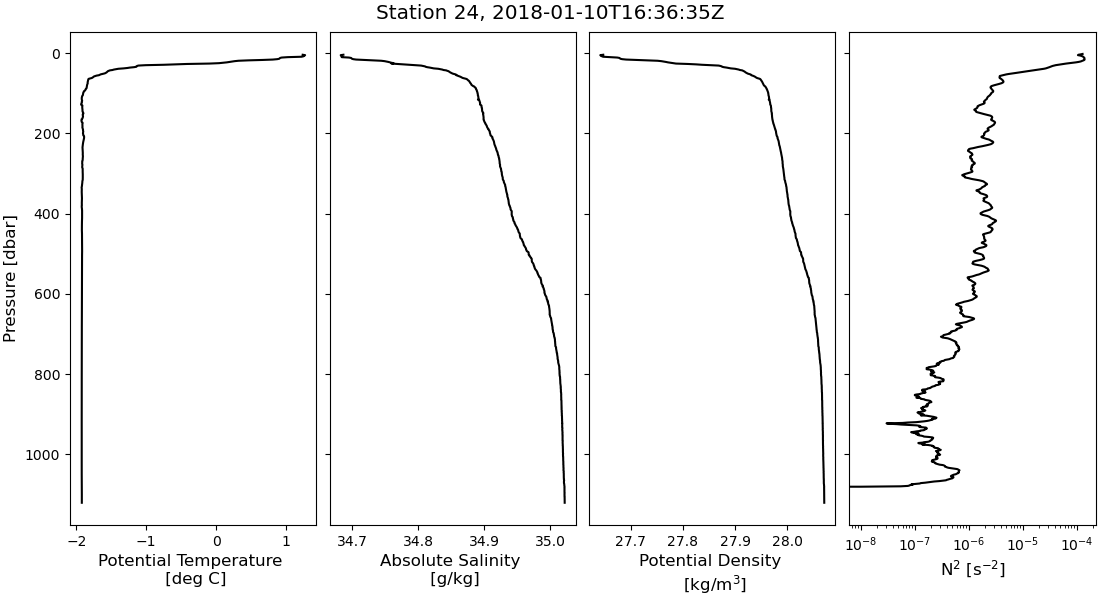

In [44]:
fig, axes = plt.subplots(1, 4, figsize=(11,6), constrained_layout=True, sharey=True)
cast = casts[24]
st=23
# 1st panel
axes[0].plot(cast.Potential_Temperature, cast.pressure,color='k')
axes[0].set_xlabel('Potential Temperature \n [deg C]')
axes[0].set_ylabel('Pressure [dbar]')
axes[0].invert_yaxis()

# 2nd panel
axes[1].plot(cast.Absolute_Salinity, cast.pressure,color='k')
axes[1].set_xlabel('Absolute Salinity \n [g/kg]')
axes[1].invert_yaxis()

# 3rd panel
axes[2].plot(cast.Potential_Density, cast.pressure,color='k')
axes[2].set_xlabel('Potential Density \n [kg/m$^3$]')
axes[2].invert_yaxis()

# 4th panel 
axes[3].semilogx(N2_casts[st],N2_casts[st].p,color='k')
axes[3].set_xlabel(r'N$^2$ [s$^{-2}$]')
# axes[3].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# axes[3].xaxis.get_offset_text().set_size(10)

# Title
st_num = cast.station.item()
date = cast.date.item()

fig.suptitle(f'Station {st_num}, {date}')

    # --- save figure ---
# filename = f'station_{st}.png'
# filepath = os.path.join(out_dir, filename)

# plt.savefig(filepath, dpi=300)
# plt.close(fig) 

C:\Users\mblan\AppData\Local\Temp\ipykernel_8316\2704623707.py:14: UserWarning: no explicit representation of timezones available for np.datetime64
  date = np.datetime64(ds.date.item())
C:\Users\mblan\AppData\Local\Temp\ipykernel_8316\2704623707.py:30: UserWarning: no explicit representation of timezones available for np.datetime64
  date = np.datetime64(ds.date.item())


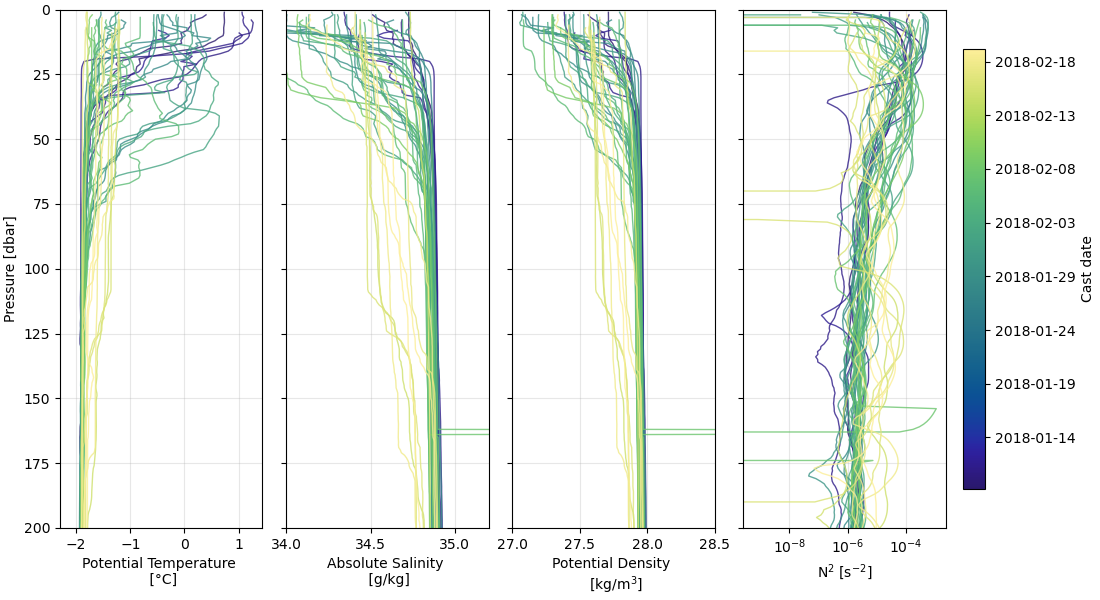

In [25]:
fig, axes = plt.subplots(
    1, 4,
    figsize=(11, 6),
    constrained_layout=True,
    sharey=True
)

# -----------------------------
# Collect cast dates for colors
# -----------------------------
cast_dates = []

for station, ds in casts.items():
    date = np.datetime64(ds.date.item())
    cast_dates.append(date)

cast_dates = np.array(cast_dates)

date_nums = mdates.date2num(cast_dates.astype('datetime64[ms]').astype(object))

norm = mcolors.Normalize(vmin=np.nanmin(date_nums), vmax=np.nanmax(date_nums))
# cmap = plt.cm.viridis
cmap = cmocean.cm.haline

# -----------------------------
# Plot all casts colored by time
# -----------------------------
for station, ds in casts.items():

    date = np.datetime64(ds.date.item())
    date_num = mdates.date2num(date.astype('datetime64[ms]').astype(object))
    color = cmap(norm(date_num))

    # Temperature
    axes[0].plot(
        ds.Potential_Temperature,
        ds.pressure,
        color=color,
        lw=1,
        alpha=0.8
    )

    # Salinity
    axes[1].plot(
        ds.Absolute_Salinity,
        ds.pressure,
        color=color,
        lw=1,
        alpha=0.8
    )

    # Density
    axes[2].plot(
        ds.Potential_Density,
        ds.pressure,
        color=color,
        lw=1,
        alpha=0.8
    )

    # N2, if station exists in N2_casts
    if station in N2_casts:
        axes[3].semilogx(
            N2_casts[station],
            N2_casts[station].p,
            color=color,
            lw=1,
            alpha=0.8
        )

# -----------------------------
# Formatting
# -----------------------------
axes[0].set_xlabel('Potential Temperature \n [°C]')
axes[0].set_ylabel('Pressure [dbar]')

axes[1].set_xlabel('Absolute Salinity \n [g/kg]')
axes[2].set_xlabel('Potential Density \n [kg/m$^3$]')
axes[3].set_xlabel(r'N$^2$ [s$^{-2}$]')

# for ax in axes:
#     ax.invert_yaxis()
#     ax.grid(alpha=0.3)

for ax in axes:
    ax.grid(alpha=0.3)

# force pressure increasing downward
pmax = np.nanmax([ds.pressure.max().item() for ds in casts.values()])
pmin = np.nanmin([ds.pressure.min().item() for ds in casts.values()])

axes[0].set_ylim(200, 0)
axes[1].set_xlim(34,35.2)
axes[2].set_xlim(27,28.5)

for ax in axes[1:]:
    plt.setp(ax.get_yticklabels(), visible=False)

# -----------------------------
# Shared colorbar for date
# -----------------------------
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cb = fig.colorbar(
    sm,
    ax=axes,
    orientation='vertical',
    shrink=0.85,
    pad=0.02
)

cb.set_label('Cast date')

# Format colorbar ticks as dates
cb.ax.yaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# fig.suptitle('2018 Terra Nova Bay CTD Casts From R/V Palmer (Map 3 Region)', fontsize=14)

plt.show()
# plt.savefig('Palmer2018_CTD_TNB_all_200m.png',dpi=400,bbox_inches='tight')

In [ ]:
# get densities at specific pressures to plot density vs time 
press_targets = [25, 50, 75, 100, 200, 300]

rho_all = []
depth_all = []

for press_target in press_targets:

    rho_list = []
    depth_list = []
    time_list = []
    station_list = []

    for st, cast in casts.items():

        rho_list.append(
            cast.Potential_Density.sel(
                pressure=press_target,
                method='nearest'
            ).item()
        )

        depth_list.append(
            cast.depth.sel(
                pressure=press_target,
                method='nearest'
            ).item()
        )

        time_list.append(pd.to_datetime(cast.date.item()))
        station_list.append(st)

    rho_all.append(rho_list)
    depth_all.append(depth_list)

rho_ds = xr.Dataset(
    data_vars={
        'Potential_Density': (
            ('pressure', 'cast'),
            np.array(rho_all)
        ),
        'Depth_Selected': (
            ('pressure', 'cast'),
            np.array(depth_all)
        ),
    },
    coords={
        'pressure': press_targets,
        'time': ('cast', time_list),
        'station': ('cast', station_list),
    }
)

Text(0.5, 0, 'Time')

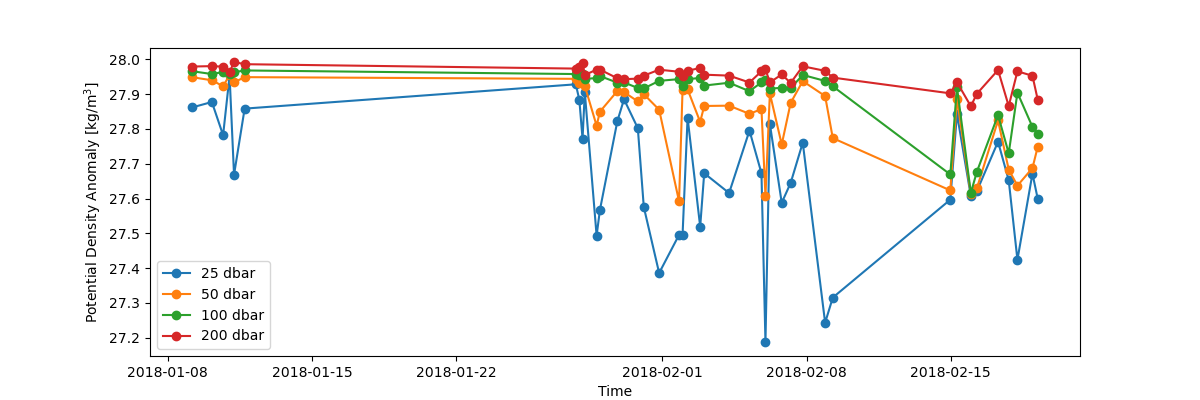

In [27]:
fig = plt.figure(figsize=(12,4))
for p in [25, 50, 100, 200]:
    plt.plot(
        rho_ds.time,
        rho_ds.Potential_Density.sel(pressure=p),
        label=f'{p} dbar',
        marker='o'
    )

plt.legend()
plt.ylabel(r'Potential Density Anomaly [kg/m$^3$]')
plt.xlabel('Time')
# plt.savefig('Density_variability_temporal.png',dpi=400)

In [28]:
# # import matplotlib.pyplot as plt
# # import numpy as np
# # import gsw

# # make output folder
# out_dir = 'ctd_TS_plots'
# os.makedirs(out_dir, exist_ok=True)

# for st, cast in casts.items():

#     # -----------------------
#     # Choose cast
#     # -----------------------
#     # st = 56
#     # cast = casts[st]

#     # -----------------------
#     # Figure layout
#     # 2 rectangular panels + 1 square-ish TS panel
#     # -----------------------
#     fig = plt.figure(figsize=(11, 5.5), constrained_layout=True)

#     gs = fig.add_gridspec(
#         nrows=1,
#         ncols=3,
#         width_ratios=[1.0, 1.0, 1.35]
#     )

#     ax_prof = fig.add_subplot(gs[0, 0])
#     ax_N2   = fig.add_subplot(gs[0, 1], sharey=ax_prof)
#     ax_TS   = fig.add_subplot(gs[0, 2])

#     # =====================================================
#     # Panel 1: Temperature + Salinity profiles, double x-axis
#     # =====================================================
#     ax_sal = ax_prof.twiny()

#     # Temperature
#     ln1 = ax_prof.plot(
#         cast.Potential_Temperature,
#         cast.pressure,
#         color='tab:blue',
#         label='Potential Temperature'
#     )

#     ax_prof.set_xlabel('Potential Temperature [°C]', color='tab:blue')
#     ax_prof.set_ylabel('Pressure [dbar]')
#     ax_prof.tick_params(axis='x', colors='tab:blue')
#     ax_prof.invert_yaxis()

#     # Salinity
#     ln2 = ax_sal.plot(
#         cast.Absolute_Salinity,
#         cast.pressure,
#         color='tab:orange',
#         label='Absolute Salinity'
#     )

#     ax_sal.set_xlabel('Absolute Salinity [g kg$^{-1}$]', color='tab:orange')
#     ax_sal.tick_params(axis='x', colors='tab:orange')

#     ax_prof.grid(alpha=0.3)
#     ax_prof.set_title('T/S Profiles')

#     # =====================================================
#     # Panel 2: N2 profile
#     # =====================================================
#     ax_N2.semilogx(
#         N2_casts[st],
#         N2_casts[st].p,
#         color='k'
#     )

#     ax_N2.set_xlabel(r'$N^2$ [s$^{-2}$]')
#     ax_N2.grid(alpha=0.3)
#     ax_N2.set_title(r'$N^2$')

#     plt.setp(ax_N2.get_yticklabels(), visible=False)

#     # =====================================================
#     # Panel 3: T/S diagram
#     # =====================================================
#     mint = -2.3
#     maxt = 1
#     mins = 34.0
#     maxs = 35.2

#     tempL = np.linspace(mint, maxt, 100)
#     salL = np.linspace(mins, maxs, 100)

#     Tg, Sg = np.meshgrid(tempL, salL)

#     lon = 165
#     lat = -75.0112
#     p_ref = 1093

#     SA_grid = gsw.SA_from_SP(Sg, p_ref, lon, lat)
#     CT_grid = gsw.CT_from_pt(SA_grid, Tg)
#     sigma_theta = gsw.sigma0(SA_grid, CT_grid)

#     # Density contours
#     cs = ax_TS.contour(
#         Sg,
#         Tg,
#         sigma_theta,
#         colors='k',
#         alpha=0.6,
#         levels=6,
#         zorder=1
#     )

#     ax_TS.clabel(cs, fontsize=9, inline=True)

#     # Freezing line
#     SA_freeze = gsw.SA_from_SP(salL, 0, lon, lat)
#     t_freezing = gsw.t_freezing(SA_freeze, p=0, saturation_fraction=0)

#     # All casts in background
#     for station, ds in casts.items():
#         ax_TS.plot(
#             ds.Absolute_Salinity,
#             ds.Potential_Temperature,
#             color='0.75',
#             lw=0.8,
#             alpha=0.5,
#             zorder=2
#         )

#     ax_TS.plot(
#         salL,
#         t_freezing,
#         'k--',
#         lw=1,
#         label='Freezing line'
#     )

#     # Cast data on T/S diagram
#     # ax_TS.plot(
#     #     cast.Absolute_Salinity,
#     #     cast.Potential_Temperature,
#     #     color='tab:purple',
#     #     lw=1.5,
#     #     zorder=3,
#     #     label='Cast'
#     # )

#     ax_TS.scatter(
#         cast.Absolute_Salinity,
#         cast.Potential_Temperature,
#         c=cast.Oxygen,
#         s=12,
#         cmap='viridis',
#         zorder=4
#     )

#     cb = fig.colorbar(
#         ax_TS.collections[-1],
#         ax=ax_TS,
#         label='Dissolved Oxygen [mL/L]',
#         shrink=0.85
#     )

#     ax_TS.set_xlabel('Absolute Salinity [g kg$^{-1}$]')
#     ax_TS.set_ylabel('Potential Temperature [°C]')
#     ax_TS.set_xlim(mins, maxs)
#     ax_TS.set_ylim(mint, maxt)
#     ax_TS.set_title('T/S Diagram')
#     ax_TS.grid(alpha=0.3)
#     ax_TS.legend(fontsize=8, loc='best')

#     # Make TS panel square-shaped
#     ax_TS.set_box_aspect(1)

#     # -----------------------
#     # Figure title
#     # -----------------------
#     st_num = cast.station.item()
#     date = cast.date.item()

#     fig.suptitle(f'Station {st_num}, {date}', fontsize=14)

#         # --- save figure ---
#     filename = f'station_{st}.png'
#     filepath = os.path.join(out_dir, filename)

#     plt.savefig(filepath, dpi=300)
#     plt.close(fig) 

In [29]:
# # Loop through casts and save plots of temp, sal, density, and N2 for each cast 
# # make output folder
# out_dir = 'ctd_plots'
# os.makedirs(out_dir, exist_ok=True)

# for st, cast in casts.items():

#     fig, axes = plt.subplots(1, 4, figsize=(11,6), constrained_layout=True, sharey=True)

#     # 1st panel
#     axes[0].plot(cast.Potential_Temperature, cast.pressure,color='k')
#     axes[0].set_xlabel('Potential Temperature \n [deg C]')
#     axes[0].set_ylabel('Pressure [dbar]')
#     axes[0].invert_yaxis()

#     # 2nd panel
#     axes[1].plot(cast.Absolute_Salinity, cast.pressure,color='k')
#     axes[1].set_xlabel('Absolute Salinity \n [g/kg]')
#     axes[1].invert_yaxis()

#     # 3rd panel
#     axes[2].plot(cast.Potential_Density, cast.pressure,color='k')
#     axes[2].set_xlabel('Potential Density \n [kg/m$^3$]')
#     axes[2].invert_yaxis()

#     # 4th panel 
#     axes[3].plot(N2_casts[st],N2_casts[st].p_mid,color='k')
#     axes[3].set_xlabel(r'N$^2$ [s$^{-1}$]')
#     axes[3].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
#     axes[3].xaxis.get_offset_text().set_size(10)

#     # Title
#     st_num = cast.station.item()
#     date = cast.date.item()

#     fig.suptitle(f'Station {st_num}, {date}')

#         # --- save figure ---
#     filename = f'station_{st}.png'
#     filepath = os.path.join(out_dir, filename)

#     plt.savefig(filepath, dpi=300)
#     plt.close(fig) 


The goal is to be able to estimate geostrophic velocity from dynamic height using two CTD casts. Each CTD cast has its own pressure coorindate and this will vary between casts. On a case by case basis, it makes sense to evaluate the pressure coordinate between casts to assess what the reference pressure should be for dynamic height calculation and what pressure grid to interpolate onto 

#### Apply Dynamic Method and Make Plots 

In [33]:
# select cast pairs to apply dynamic method analysis 
cast1 = casts[38]
cast2 = casts[52]

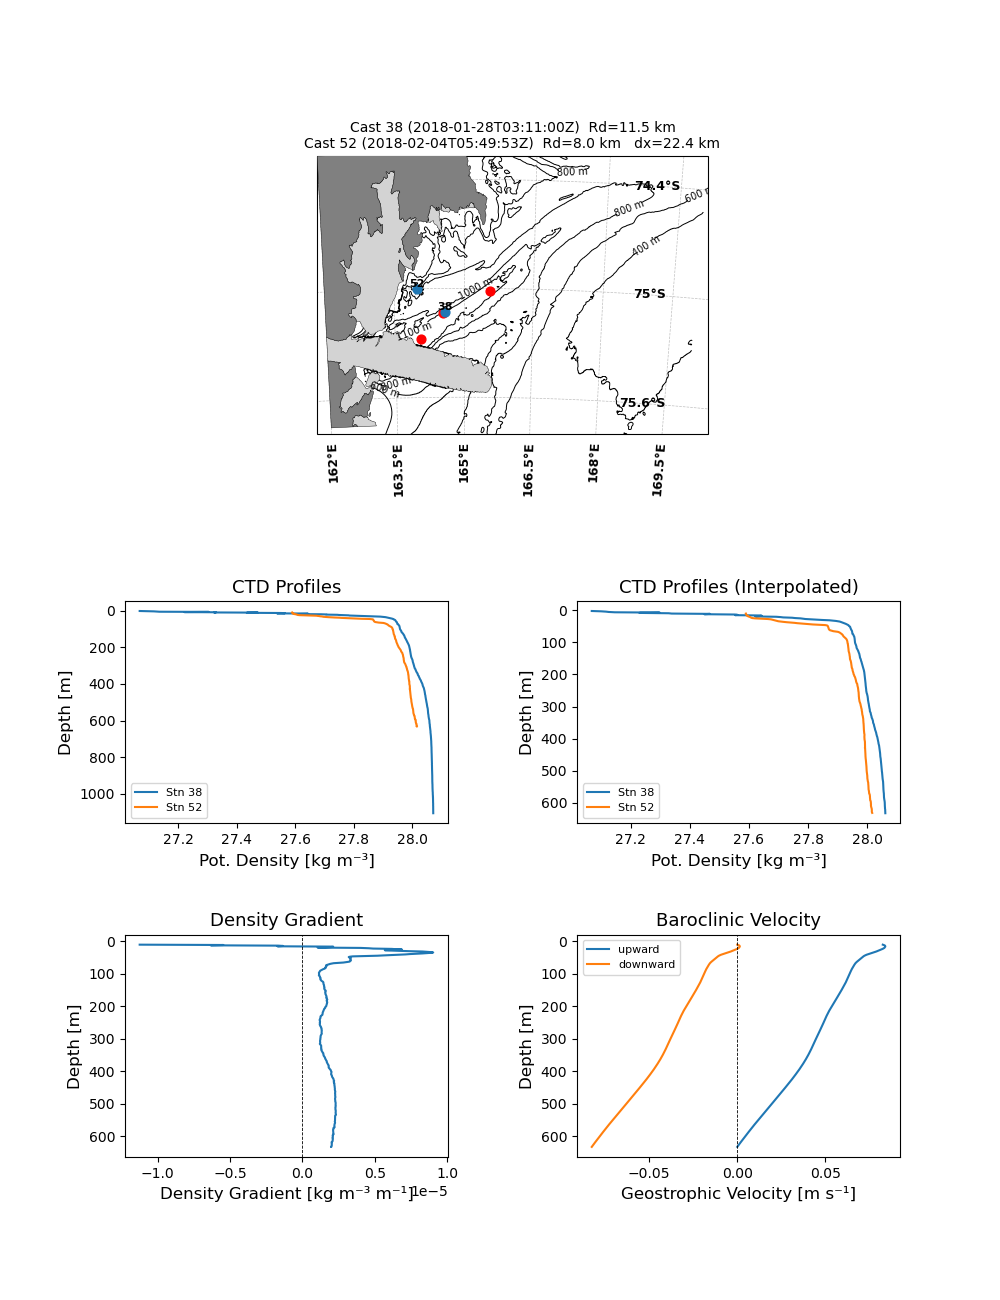

In [34]:
fig, axes = plot_tw_geo_vel_summary(
    cast1, cast2,
    bath, ice_clip, land_clip,
    Rd_casts,
    ditd_lon, ditd_lat,
    tnbd_lon, tnbd_lat,
    D_lon, D_lat,
    lat_min, lat_max,
    lon_min, lon_max,
    int_from_top=False,
    save_path=None,   # or .pdf / .svg
)
plt.show()

In [35]:
(cast1_depth, cast2_depth,
    cast1_depth_interp, cast2_depth_interp,
    dx, drho_dx, shear, v_tw) = tw_geo_vel(cast1, cast2, int_from_top=False)

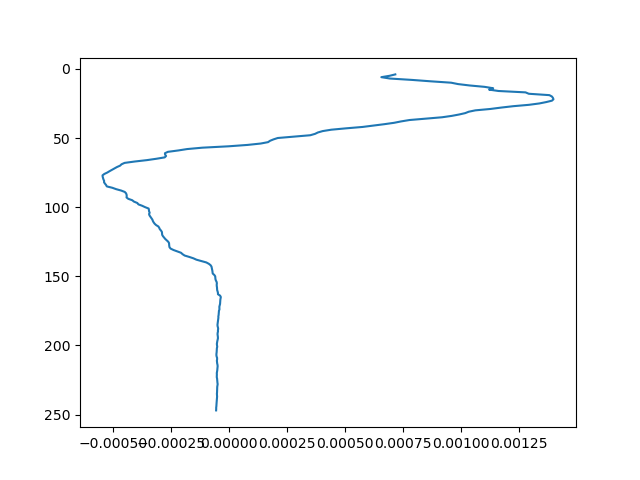

In [45]:
fig = plt.figure()
plt.plot(shear,shear.depth)
plt.gca().invert_yaxis()

In [37]:
# define casts to get baroclinic velocity profile between 
# NOTE: put in eastward cast as cast 1 - defining East as x positive direction 

cast1 = [38, 26, 56, 37, 37, 22, 22, 22, 22, 22, 22, 24, 24, 24, 24, 23, 23, 23, 27, 27, 36, 36, 60, 60, 76, 76, 55]
cast2 = [52, 39, 47, 47, 57, 57, 48, 58, 74, 72, 54, 48, 58, 74, 72, 80, 75, 61, 41, 61, 40, 77, 40, 77, 40, 77, 79]

In [38]:
results = {}

for st1, st2 in zip(cast1, cast2):

    c1 = casts[st1]
    c2 = casts[st2]

    # calculate time difference
    t1 = pd.to_datetime(c1.date.item())
    t2 = pd.to_datetime(c2.date.item())

    dt = t2 - t1
    dt_hours = abs(dt.total_seconds()) / 3600

    (cast1_depth, cast2_depth,
     cast1_depth_interp, cast2_depth_interp,
     dx, drho_dx, shear, v_tw) = tw_geo_vel(
        c1, c2, int_from_top=False
    )

    # --------------------------------------------------
    # Drop NaNs so drho_dx / shear match v_tw length
    # --------------------------------------------------
    # valid = np.isfinite(drho_dx) & np.isfinite(shear)

    drho_dx_clean = drho_dx.dropna(dim='depth')
    shear_clean = shear.dropna(dim='depth')

    # Trim v_tw to match cleaned arrays
    # v_tw_clean = v_tw[valid.values]

    # Use the cleaned coordinate from drho_dx
    depth_coord = drho_dx_clean.depth

    # --------------------------------------------------
    # Build dataset
    # --------------------------------------------------
    ds_out = xr.Dataset(
        data_vars={
            "drho_dx": drho_dx_clean,
            "shear": shear_clean,
            "v_tw": (
                drho_dx_clean.dims,
                v_tw
            ),
        },
        coords={
            drho_dx_clean.dims[0]: depth_coord
        },
        attrs={
            "cast1": st1,
            "cast2": st2,
            "pair": f"{st1}_{st2}",
            "dx": dx,
            "dt_hours": dt_hours,
            "date1": str(t1),
            "date2": str(t2),
            "int_from_top": False,
        }
    )

    results[(st1, st2)] = ds_out

In [39]:
summary = []

for pair, ds in results.items():

    summary.append({
        "pair": pair,
        "dx_km": ds.attrs["dx"] / 1000,
        "dt_hours": ds.attrs["dt_hours"],
    })

summary = pd.DataFrame(summary)

Text(0, 0.5, 'Time separation [hours]')

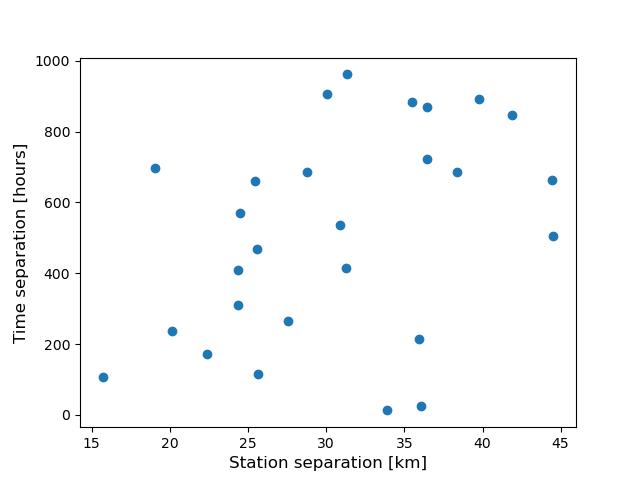

In [41]:
fig = plt.figure()
plt.scatter(summary.dx_km, summary.dt_hours)
plt.xlabel("Station separation [km]")
plt.ylabel("Time separation [hours]")

In [43]:
results.keys()

dict_keys([(38, 52), (26, 39), (56, 47), (37, 47), (37, 57), (22, 57), (22, 48), (22, 58), (22, 74), (22, 72), (22, 54), (24, 48), (24, 58), (24, 74), (24, 72), (23, 80), (23, 75), (23, 61), (27, 41), (27, 61), (36, 40), (36, 77), (60, 40), (60, 77), (76, 40), (76, 77), (55, 79)])

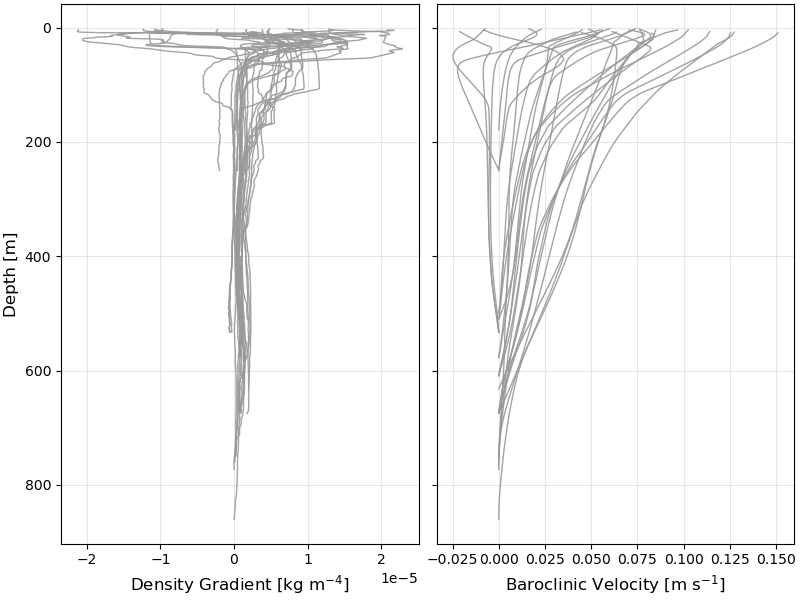

In [44]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(8, 6),
    constrained_layout=True,
    sharey=True
)

for pair, ds in results.items():

    zdim = ds.drho_dx.dims[0]   # depth coordinate dimension
    z = ds[zdim]

    # Panel 1: density gradient
    axes[0].plot(
        ds.drho_dx,
        z,
        color='0.6',
        lw=1,
        alpha=0.9
    )

    # Panel 2: thermal wind velocity
    axes[1].plot(
        ds.v_tw,
        z,
        color='0.6',
        lw=1,
        alpha=0.9
    )

axes[0].set_xlabel(r'Density Gradient [kg m$^{-4}$]')
axes[0].set_ylabel('Depth [m]')

axes[1].set_xlabel(r'Baroclinic Velocity [m s$^{-1}$]')

for ax in axes:
    ax.grid(alpha=0.3)

# Force depth increasing downward
# zmax = max([float(ds[ds.drho_dx.dims[0]].max()) for ds in results.values()])
# zmin = min([float(ds[ds.drho_dx.dims[0]].min()) for ds in results.values()])
# axes[0].set_ylim(zmax, zmin)

axes[0].invert_yaxis()


plt.show()

# plt.savefig('Baroclinic_velocity_allpairs.png',dpi=400,bbox_inches='tight')

#### Estimate mean baroclinic velocity profile and shade with +/- 1 std 

In [46]:
z_common = np.arange(0, 600, 5)   # adjust max depth + spacing

In [47]:
v_list = []

for pair, res in results.items():
    
    v = res['v_tw']   # assuming dictionary structure
    z = res['depth']  # or however you stored depth

    # convert to DataArray if needed
    v_da = xr.DataArray(v, dims=['depth'], coords={'depth': z})

    # interpolate
    v_interp = v_da.interp(depth=z_common)

    # add pair as coordinate
    v_interp = v_interp.expand_dims(pair=[str(pair)])

    v_list.append(v_interp)

In [48]:
v_all = xr.concat(v_list, dim='pair')

In [49]:
v_all

<xarray.DataArray 'v_tw' (pair: 27, depth: 120)> Size: 26kB
array([[        nan,         nan,  0.08259502, ...,  0.00660859,
         0.00588609,  0.00516183],
       [        nan,         nan,  0.04577024, ...,  0.01236723,
         0.01187433,  0.01138298],
       [        nan,  0.0536877 ,  0.04726054, ...,         nan,
                nan,         nan],
       ...,
       [        nan, -0.0082906 , -0.00983593, ...,         nan,
                nan,         nan],
       [        nan,  0.07651194,  0.07731154, ...,  0.00207158,
         0.00162356,  0.00119348],
       [        nan, -0.00745307, -0.00361634, ...,         nan,
                nan,         nan]], shape=(27, 120))
Coordinates:
  * pair     (pair) object 216B '(38, 52)' '(26, 39)' ... '(76, 77)' '(55, 79)'
  * depth    (depth) int64 960B 0 5 10 15 20 25 30 ... 570 575 580 585 590 595

In [50]:
v_mean = v_all.mean(dim='pair')
v_std  = v_all.std(dim='pair')
v_se   = v_std / np.sqrt(v_all.sizes['pair'])

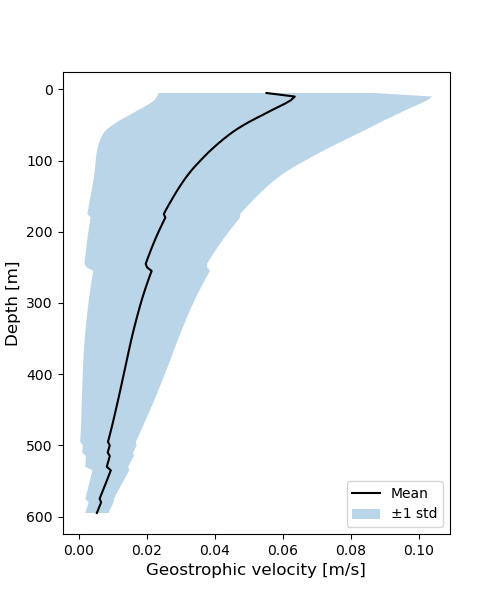

In [51]:
fig, ax = plt.subplots(figsize=(5,6))

ax.plot(v_mean, v_mean.depth, color='k', label='Mean')

ax.fill_betweenx(
    v_mean.depth,
    v_mean - v_std,
    v_mean + v_std,
    alpha=0.3,
    label='±1 std'
)

ax.invert_yaxis()
ax.set_xlabel('Geostrophic velocity [m/s]')
ax.set_ylabel('Depth [m]')
ax.legend()
# plt.savefig('mean_baroclinic_velocity_std.png',dpi=400)

In [52]:
rms = np.sqrt(
    ((v_all - v_mean)**2).mean(dim='depth')
)

In [53]:
rms.values

array([0.02306016, 0.02315064, 0.04338803, 0.02564243, 0.00591754,
       0.0137385 , 0.01097135, 0.01622014, 0.03451504, 0.01573923,
       0.03620968, 0.01038122, 0.01257865, 0.02745387, 0.01104156,
       0.0360774 , 0.02458639, 0.00435744, 0.01663705, 0.00513329,
       0.02824618, 0.00877659, 0.03341858, 0.01110634, 0.03671052,
       0.01098302, 0.02689864])

In [54]:
dt_hours = np.array([
    ds.attrs['dt_hours']
    for ds in results.values()
])

In [55]:
dt_hours

array([170.64805556, 408.45638889, 105.76527778, 116.10916667,
       235.67611111, 686.39944444, 570.89472222, 696.7975    ,
       906.62361111, 882.72055556, 662.80472222, 535.00277778,
       660.90555556, 870.73166667, 846.82861111, 961.68416667,
       890.84444444, 723.04916667, 413.745     , 684.89027778,
        24.21916667, 504.12083333, 266.11      , 213.79166667,
       467.46222222,  12.43944444, 310.91      ])

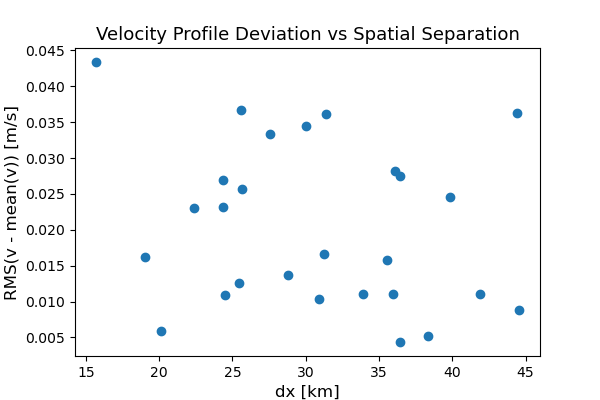

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(dx_km, rms)

plt.xlabel('dx [km]')
plt.ylabel('RMS(v - mean(v)) [m/s]')
plt.title('Velocity Profile Deviation vs Spatial Separation')
# plt.savefig('RMS_V_dx.png',dpi=400)


In [57]:
plt.close('all')

In [58]:
dt_hours = []
v_mean_pair = []

for pair, ds in results.items():

    dt_hours.append(ds.attrs['dt_hours'])

    v_mean_pair.append(
        np.nanmean(np.abs(ds.v_tw))
    )

dt_hours = np.array(dt_hours)
v_mean_pair = np.array(v_mean_pair)

Text(0.5, 1.0, 'Baroclinic Velocity vs Time Separation')

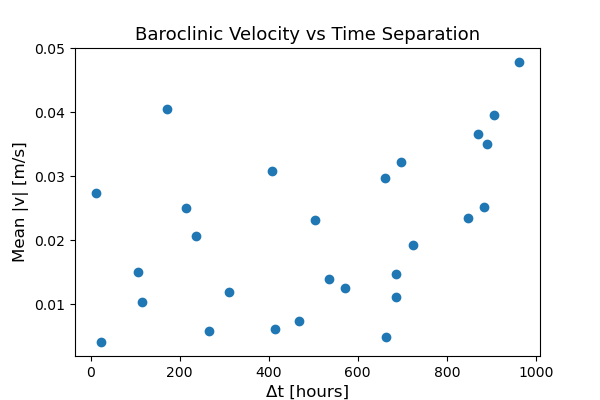

In [59]:
plt.figure(figsize=(6,4))

plt.scatter(dt_hours, v_mean_pair)

plt.xlabel('Δt [hours]')
plt.ylabel('Mean |v| [m/s]')
plt.title('Baroclinic Velocity vs Time Separation')

In [60]:
dt_hours = []
dx_km = []
pairs = []

for pair, ds in results.items():

    dt_hours.append(ds.attrs['dt_hours'])
    dx_km.append(ds.attrs['dx'] / 1000)   # convert m -> km
    pairs.append(pair)

dt_hours = np.array(dt_hours)
dx_km = np.array(dx_km)

Text(0.5, 1.0, 'Cast-Pair Spatial Separation')

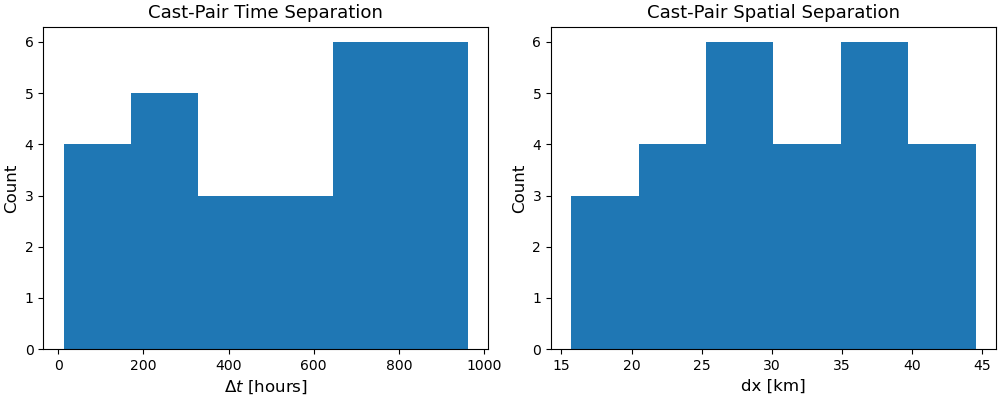

In [61]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    constrained_layout=True
)

# -------------------------
# Δt histogram
# -------------------------
axes[0].hist(dt_hours, bins='auto')

axes[0].set_xlabel(r'$\Delta t$ [hours]')
axes[0].set_ylabel('Count')
axes[0].set_title('Cast-Pair Time Separation')

# -------------------------
# dx histogram
# -------------------------
axes[1].hist(dx_km, bins='auto')

axes[1].set_xlabel('dx [km]')
axes[1].set_ylabel('Count')
axes[1].set_title('Cast-Pair Spatial Separation')

# plt.savefig('dt_dx_histograms.png',dpi=400)

#### Assess Temporal Variability 

In [135]:
results[(38,52)]

<xarray.Dataset> Size: 20kB
Dimensions:  (depth: 623)
Coordinates:
  * depth    (depth) float64 5kB 10.0 11.0 12.0 13.0 ... 629.0 630.0 631.0 632.0
Data variables:
    drho_dx  (depth) float64 5kB -1.123e-05 -5.461e-06 ... 1.975e-06 1.977e-06
    shear    (depth) float64 5kB 0.0007605 0.0003698 ... -0.0001337 -0.0001339
    v_tw     (depth) float64 5kB 0.0826 0.08316 0.08356 ... 0.0001338 0.0
Attributes:
    cast1:         38
    cast2:         52
    pair:          38_52
    dx:            22351.27955648225
    dt_hours:      170.64805555555554
    date1:         2018-01-28 03:11:00+00:00
    date2:         2018-02-04 05:49:53+00:00
    int_from_top:  False

In [100]:
v_list = []
dt_list = []
pair_list = []

z_common = np.arange(0, 600, 5)

for pair, res in results.items():
    v = res['v_tw']
    z = res['depth']          # or res['v_tw'].depth if already DataArray
    dt = res.attrs['dt_hours']

    v_da = xr.DataArray(v, dims=['depth'], coords={'depth': z})
    v_interp = v_da.interp(depth=z_common)

    v_list.append(v_interp)
    dt_list.append(dt)
    pair_list.append(str(pair))

v_all = xr.concat(v_list, dim='pair')
v_all = v_all.assign_coords(
    pair=pair_list,
    dt_hours=('pair', dt_list)
)

In [119]:
short = v_all.where(v_all.dt_hours <= 72, drop=True)
long  = v_all.where(v_all.dt_hours > 72, drop=True)

v_short_mean = short.mean(dim='pair')
v_long_mean = long.mean(dim='pair')

temporal_bias = v_long_mean - v_short_mean

In [120]:
short

<xarray.DataArray 'v_tw' (pair: 2, depth: 120)> Size: 2kB
array([[            nan,  1.83295242e-02,  2.07070595e-02,
         1.99760429e-02,  1.68014065e-02,  1.28049840e-02,
         8.96601597e-03,  6.06113615e-03,  3.77573067e-03,
         1.96296059e-03,  5.24811679e-04, -4.56095530e-04,
        -1.19110667e-03, -1.70633047e-03, -2.11921551e-03,
        -2.40746583e-03, -2.62378247e-03, -2.81074773e-03,
        -2.96696355e-03, -3.10769721e-03, -3.22486259e-03,
        -3.33010893e-03, -3.42641322e-03, -3.50597990e-03,
        -3.57085047e-03, -3.61907568e-03, -3.67027369e-03,
        -3.71858668e-03, -3.76332199e-03, -3.81033053e-03,
        -3.86086177e-03, -3.91146353e-03, -3.95523170e-03,
        -3.99749588e-03, -4.03540381e-03, -4.06717267e-03,
        -4.09392718e-03, -4.11201917e-03, -4.14168815e-03,
        -4.17578775e-03, -4.20261292e-03, -4.22591904e-03,
        -4.25359974e-03, -4.28518018e-03, -4.31089131e-03,
        -4.32729639e-03, -4.34234394e-03, -4.36132036e-03,
        -4.37829365e-03, -4.39551126e-03, -4.42060024e-03,
        -4.44384275e-03, -4.45972956e-03, -4.46958562e-03,
        -4.48510230e-03, -4.50181757e-03, -4.51021432e-03,
        -4.51282416e-03, -4.50894649e-03, -4.50062754e-03,
...
         1.82460709e-02,  1.79311002e-02,  1.76391598e-02,
         1.73546577e-02,  1.70710431e-02,  1.67827682e-02,
         1.64945309e-02,  1.62151710e-02,  1.59470189e-02,
         1.56868541e-02,  1.54289839e-02,  1.51759066e-02,
         1.49320610e-02,  1.47010535e-02,  1.44786628e-02,
         1.42606082e-02,  1.40465253e-02,  1.38331823e-02,
         1.36163900e-02,  1.33952111e-02,  1.31671005e-02,
         1.29335441e-02,  1.26965239e-02,  1.24519615e-02,
         1.22084039e-02,  1.19658138e-02,  1.17164413e-02,
         1.14675670e-02,  1.12135155e-02,  1.09581348e-02,
         1.06972464e-02,  1.04406333e-02,  1.01951699e-02,
         9.94687441e-03,  9.69987370e-03,  9.45488140e-03,
         9.21227016e-03,  8.96697410e-03,  8.72057317e-03,
         8.46392123e-03,  8.18961600e-03,  7.91485622e-03,
         7.62038742e-03,  7.31960721e-03,  7.01687346e-03,
         6.71712994e-03,  6.40998886e-03,  6.08055749e-03,
         5.72469865e-03,  5.36187480e-03,  4.99755982e-03,
         4.61596531e-03,  4.21273818e-03,  3.79486498e-03,
         3.37213336e-03,  2.94740728e-03,  2.51643569e-03,
         2.07157768e-03,  1.62355531e-03,  1.19347815e-03]])
Coordinates:
  * pair      (pair) <U8 64B '(36, 40)' '(76, 77)'
    dt_hours  (pair) float64 16B 24.22 12.44
  * depth     (depth) int64 960B 0 5 10 15 20 25 30 ... 570 575 580 585 590 595

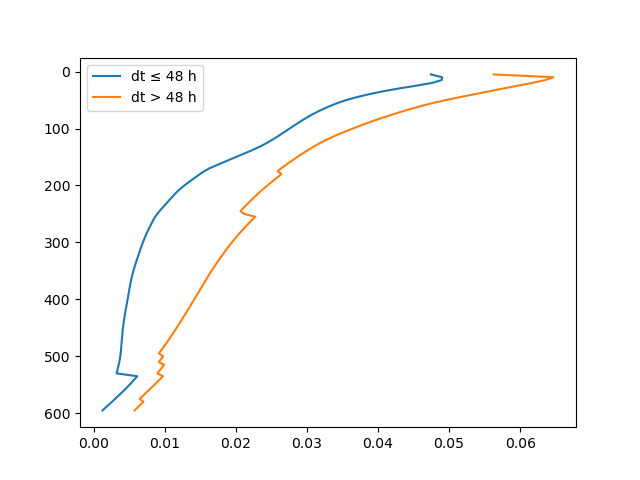

In [121]:
fig = plt.figure()
plt.plot(v_short_mean, z_common, label='dt ≤ 48 h')
plt.plot(v_long_mean, z_common, label='dt > 48 h')
plt.gca().invert_yaxis()
plt.legend()

In [103]:
v_std_all = v_all.std(dim='pair')

In [104]:
v_std_short = short.std(dim='pair')

In [105]:
temporal_component = np.sqrt(v_std_all**2 - v_std_short**2)

c:\Users\mblan\miniforge3\envs\ocean\Lib\site-packages\xarray\computation\apply_ufunc.py:820: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


In [106]:
temporal_component = xr.where(
    v_std_all > v_std_short,
    np.sqrt(v_std_all**2 - v_std_short**2),
    0
)

In [107]:
temporal_component

<xarray.DataArray 'v_tw' (depth: 120)> Size: 960B
array([0.        , 0.01270011, 0.02889417, 0.02777283, 0.02514779,
       0.02235657, 0.01999002, 0.01847012, 0.01741211, 0.01670091,
       0.01621039, 0.01585957, 0.01519445, 0.01423407, 0.01311272,
       0.01190758, 0.01053492, 0.00904306, 0.00730101, 0.00511929,
       0.00055624, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00252411,
       0.0053472 , 0.00709883, 0.00846202, 0.00959578, 0.01052206,
       0.01102802, 0.0110617 , 0.01126844, 0.01146591, 0.01165224,
       0.01180757, 0.01191385, 0.01196879, 0.01194358, 0.01189894,
       0.01185669, 0.01181524, 0.01179613, 0.01180115, 0.01180559,
       0.01163678, 0.01113226, 0.0110714 , 0.01098433, 0.01089505,
       0.0108135 , 0.01073367, 0.01065543, 0.01057078, 0.01048486,
       0.01040309, 0.01032385, 0.0102339 , 0.01014407, 0.01005804,
       0.00998299, 0.00991536, 0.00983724, 0.00975339, 0.00966663,
       0.00958087, 0.00949604, 0.00940989, 0.00932058, 0.00922818,
       0.00913304, 0.00903364, 0.00892986, 0.00882494, 0.00871784,
       0.00861206, 0.00850892, 0.0084088 , 0.00831355, 0.00821151,
       0.00810968, 0.00801139, 0.00791186, 0.00781006, 0.0077089 ,
       0.0076093 , 0.0075096 , 0.00740301, 0.00729834, 0.00719369,
       0.00708963, 0.0069864 , 0.0068884 , 0.00678883, 0.00669192,
       0.00649938, 0.00638459, 0.00627464, 0.00589782, 0.00573421,
       0.00556687, 0.00540195, 0.0054282 , 0.00525814, 0.00509101,
       0.0049295 , 0.0047739 , 0.00462593, 0.00448943, 0.00435792,
       0.00423252, 0.00368673, 0.00358995, 0.00349908, 0.00340961])
Coordinates:
  * depth    (depth) int64 960B 0 5 10 15 20 25 30 ... 570 575 580 585 590 595

In [108]:
ratio = temporal_component / np.abs(v_mean)

In [109]:
ratio

<xarray.DataArray 'v_tw' (depth: 120)> Size: 960B
array([       nan, 0.22994027, 0.45480693, 0.44478548, 0.41468615,
       0.38201231, 0.35428991, 0.33930726, 0.33253157, 0.33147997,
       0.33403473, 0.33882609, 0.33576608, 0.32452626, 0.30822357,
       0.28844778, 0.26284199, 0.23229453, 0.19291209, 0.13908849,
       0.01553783, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.08822499,
       0.19108649, 0.25933982, 0.31606536, 0.36654627, 0.41102522,
       0.43999746, 0.43367302, 0.45069482, 0.46804727, 0.48543778,
       0.50205088, 0.5169415 , 0.52986947, 0.5392774 , 0.54781944,
       0.55648257, 0.5652469 , 0.57515892, 0.58655801, 0.59811214,
       0.57758966, 0.51813799, 0.52502562, 0.53042864, 0.53561322,
       0.54125102, 0.54699191, 0.55265459, 0.55781315, 0.56280489,
       0.56788557, 0.57299107, 0.57731807, 0.58153122, 0.58604033,
       0.59121271, 0.59682444, 0.60176891, 0.60623286, 0.61048002,
       0.6147585 , 0.6189292 , 0.62287494, 0.62647265, 0.62983925,
       0.63307182, 0.63613962, 0.6390013 , 0.64191467, 0.64490384,
       0.64805546, 0.65137474, 0.65503849, 0.65928256, 0.6632762 ,
       0.66744377, 0.67225409, 0.67727705, 0.68240105, 0.68790559,
       0.69396909, 0.70023345, 0.7062912 , 0.71290608, 0.72015268,
       0.72831876, 0.7376539 , 0.74839848, 0.75994617, 0.7731256 ,
       0.70867485, 0.71916517, 0.73146448, 0.64177373, 0.6446878 ,
       0.64743901, 0.65084958, 0.57249215, 0.57885359, 0.58638022,
       0.59570716, 0.60732796, 0.62148989, 0.63883159, 0.65903953,
       0.68270684, 0.55521459, 0.57738737, 0.60324383, 0.63270475])
Coordinates:
  * depth    (depth) int64 960B 0 5 10 15 20 25 30 ... 570 575 580 585 590 595

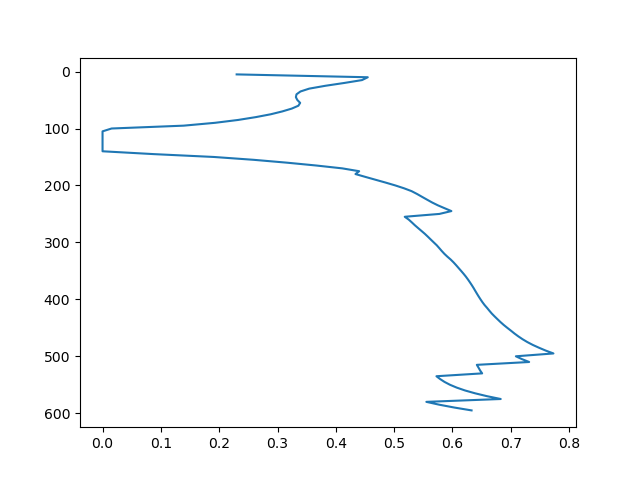

In [110]:
fig = plt.figure()
plt.plot(ratio,ratio.depth)
plt.gca().invert_yaxis()

In [112]:
v_mean

<xarray.DataArray 'v_tw' (depth: 120)> Size: 960B
array([       nan, 0.05523221, 0.06353062, 0.06244096, 0.06064295,
       0.05852317, 0.05642278, 0.05443481, 0.05236229, 0.05038286,
       0.04852907, 0.04680742, 0.04525307, 0.04386107, 0.04254289,
       0.0412816 , 0.04008081, 0.03892928, 0.0378463 , 0.036806  ,
       0.03579926, 0.03481818, 0.0338581 , 0.032961  , 0.03213914,
       0.03135959, 0.03062836, 0.02992656, 0.02925912, 0.02860996,
       0.02798314, 0.0273727 , 0.02677299, 0.02617892, 0.02559956,
       0.02506384, 0.025507  , 0.02500237, 0.02449733, 0.02400357,
       0.02351868, 0.0230468 , 0.02258819, 0.02214739, 0.02172055,
       0.02130649, 0.02090279, 0.02050935, 0.02011933, 0.01973808,
       0.02014714, 0.02148513, 0.02108735, 0.0207084 , 0.02034126,
       0.01997871, 0.01962309, 0.01928044, 0.0189504 , 0.01862966,
       0.018319  , 0.01801747, 0.01772662, 0.01744372, 0.01716271,
       0.01688561, 0.01661353, 0.01634721, 0.01608852, 0.01583448,
       0.01558477, 0.01534269, 0.01510718, 0.01487787, 0.01465164,
       0.01442654, 0.01420072, 0.01397472, 0.01374785, 0.01351805,
       0.01328908, 0.01306301, 0.0128371 , 0.01261   , 0.01238022,
       0.01215036, 0.01191721, 0.01168187, 0.01144497, 0.01120633,
       0.01096489, 0.01072442, 0.01048152, 0.01023744, 0.00998912,
       0.00973424, 0.00947111, 0.00920418, 0.0089333 , 0.00865567,
       0.00917118, 0.00887778, 0.00857819, 0.00918988, 0.00889455,
       0.00859829, 0.00829985, 0.0094817 , 0.00908371, 0.00868209,
       0.00827504, 0.0078605 , 0.00744329, 0.00702757, 0.00661253,
       0.00619961, 0.00664019, 0.00621758, 0.00580044, 0.00538895])
Coordinates:
  * depth    (depth) int64 960B 0 5 10 15 20 25 30 ... 570 575 580 585 590 595

In [113]:
z

<xarray.DataArray 'depth' (depth: 244)> Size: 2kB
array([  4.,   5.,   6., ..., 245., 246., 247.], shape=(244,))
Coordinates:
  * depth    (depth) float64 2kB 4.0 5.0 6.0 7.0 8.0 ... 244.0 245.0 246.0 247.0

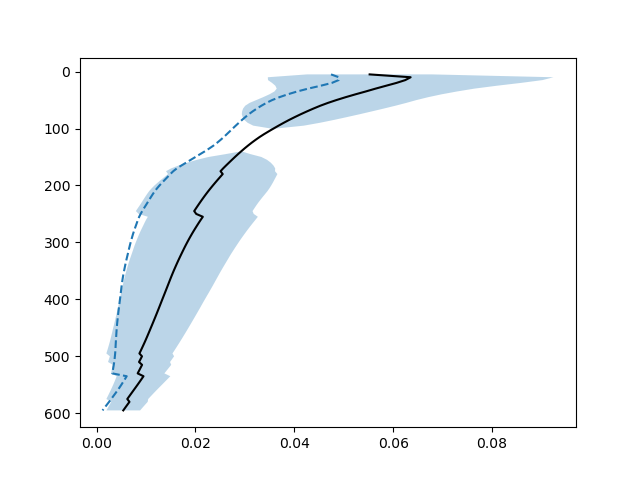

In [117]:
fig = plt.figure()
plt.plot(v_mean, v_mean.depth, 'k', label='Mean')

plt.fill_betweenx(
    v_mean.depth,
    v_mean - temporal_component,
    v_mean + temporal_component,
    alpha=0.3,
    label='Temporal variability'
)

plt.plot(v_short_mean, v_mean.depth, '--', label='Synoptic')
plt.gca().invert_yaxis()

#### Make table of data and save as latex file 

In [44]:
rows = []

for pair, ds in results.items():

    zdim = ds.drho_dx.dims[0]
    z = ds[zdim]

    max_depth = float(z.max())
    dx_km = ds.attrs['dx'] / 1000
    mean_v_tw = float(ds.v_tw.mean(skipna=True))

    drho_dx_vals = ds.drho_dx.values
    idx_max_mag = np.nanargmax(np.abs(drho_dx_vals))
    max_drho_dx_mag = drho_dx_vals[idx_max_mag]

    rows.append({
        'Pair': f'{pair[0]}–{pair[1]}',
        'Dist. (km)': dx_km,
        'Depth (m)': max_depth,
        'Mean $v_{TW}$ (m s$^{-1}$)': mean_v_tw,
        'Max $|\\partial \\rho / \\partial x|$': max_drho_dx_mag
    })

table = pd.DataFrame(rows)

# Sort while columns are still numeric
table = table.sort_values(by='Depth (m)', ascending=True).reset_index(drop=True)

# ----------------------------
# Formatting helpers
# ----------------------------
def trim_zeros(x, precision=2):
    if pd.isna(x):
        return ''
    return f"{float(x):.{precision}f}".rstrip('0').rstrip('.')

def sci_notation_latex(x, precision=2):
    if pd.isna(x):
        return ''
    if x == 0:
        return "$0$"
    exponent = int(np.floor(np.log10(abs(x))))
    coeff = x / 10**exponent
    return f"${coeff:.{precision}f} \\times 10^{{{exponent}}}$"

# ----------------------------
# Format for display/export
# ----------------------------
table['Dist. (km)'] = table['Dist. (km)'].apply(lambda x: trim_zeros(x, 2))
table['Depth (m)'] = table['Depth (m)'].apply(lambda x: trim_zeros(x, 1))
table['Mean $v_{TW}$ (m s$^{-1}$)'] = table['Mean $v_{TW}$ (m s$^{-1}$)'].apply(lambda x: trim_zeros(x, 4))

col = 'Max $|\\partial \\rho / \\partial x|$'
table[col] = table[col].apply(lambda x: sci_notation_latex(x, 2))

table

,Pair,Dist. (km),Depth (m),Mean $v_{TW}$ (m s$^{-1}$),Max $|\partial \rho / \partial x|$
0,22–54,44.42,179,0.0048,$9.22 \times 10^{-6}$
1,55–79,24.33,247,0.0115,$-2.06 \times 10^{-5}$
2,56–47,15.7,250,-0.0059,$2.29 \times 10^{-5}$
3,37–47,25.63,250,0.0103,$1.55 \times 10^{-5}$
4,24–72,41.88,499,0.0235,$7.73 \times 10^{-6}$
5,22–72,35.52,499,0.0252,$9.36 \times 10^{-6}$
6,37–57,20.15,510,0.0207,$-2.13 \times 10^{-5}$
7,22–57,28.79,510,0.0111,$1.08 \times 10^{-5}$
8,36–40,36.06,533,-0.002,$1.20 \times 10^{-5}$
9,76–40,25.56,533,-0.0073,$1.07 \times 10^{-5}$


In [45]:
# latex_table = table.to_latex(
#     "thermal_wind_table.tex",
#     index=False,
#     escape=False
# )

#### Load in Mooring D data to compare with Cast 38 to get reference velocity direction 

Ideally, we would like to compare the velocity at the shallowest sensor (~550 meters), but that one stopped collecting data in Dec. 2017. We need to compare with cast 38 which was taken at 2018-01-28. Mooring D has data for that time at 911 and 1135 meters. Trying to compare this to baroclinic velocity profiles that only go down to ~600 meters. We could potentially extrapolate this down to 900 meters. Would be good to compare velocity at Mooring D for all depths to see if there is consistenty in direction. 

In [46]:
moorings = xr.open_datatree('/Users/mblan/Documents/research/TNB_tools/preprocess/TNB_Moorings_DataTree.nc')

In [47]:
D_vel_top = moorings['D/2017/vel/top']
D_vel_mid = moorings['D/2017/vel/mid']
D_vel_bot = moorings['D/2017/vel/bot']

In [48]:
moorings['D/2017/vel/bot'].z.values

array(1135.)

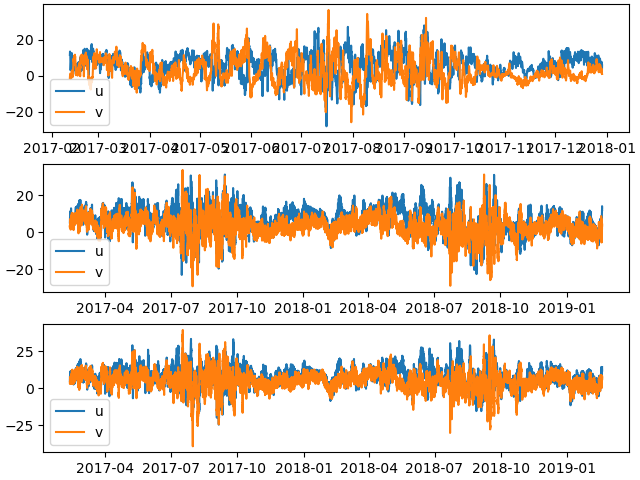

In [49]:
fig, axes = plt.subplots(nrows=3,ncols=1,constrained_layout=True)

axes[0].plot(D_vel_top.time,D_vel_top.u,label='u')
axes[0].plot(D_vel_top.time,D_vel_top.v,label='v')
axes[0].legend()

axes[1].plot(D_vel_mid.time,D_vel_mid.u,label='u')
axes[1].plot(D_vel_mid.time,D_vel_mid.v,label='v')
axes[1].legend()

axes[2].plot(D_vel_bot.time,D_vel_bot.u,label='u')
axes[2].plot(D_vel_bot.time,D_vel_bot.v,label='v')
axes[2].legend()

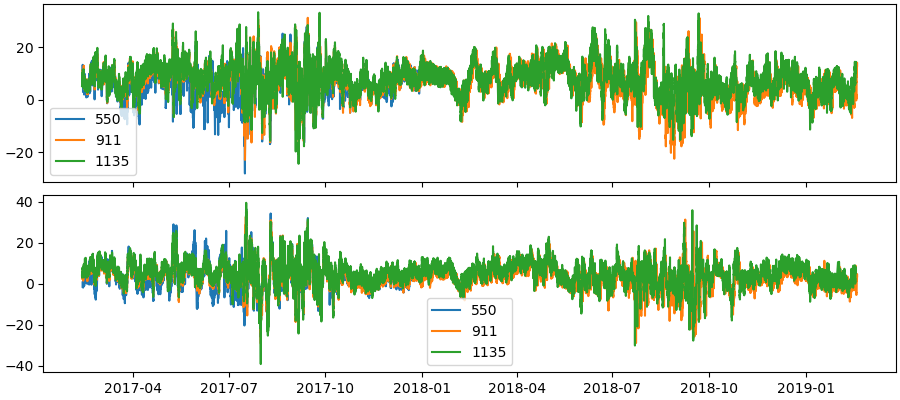

In [50]:
fig, axes = plt.subplots(nrows=2,ncols=1,constrained_layout=True,figsize=(9,4),sharex=True)

axes[0].plot(D_vel_top.time,D_vel_top.u,label='550')
axes[0].plot(D_vel_mid.time,D_vel_mid.u,label='911')
axes[0].plot(D_vel_bot.time,D_vel_bot.u,label='1135')
axes[0].legend()

axes[1].plot(D_vel_top.time,D_vel_top.v,label='550')
axes[1].plot(D_vel_mid.time,D_vel_mid.v,label='911')
axes[1].plot(D_vel_bot.time,D_vel_bot.v,label='1135')
axes[1].legend()

Text(0.01, 0.05, '1135 m')

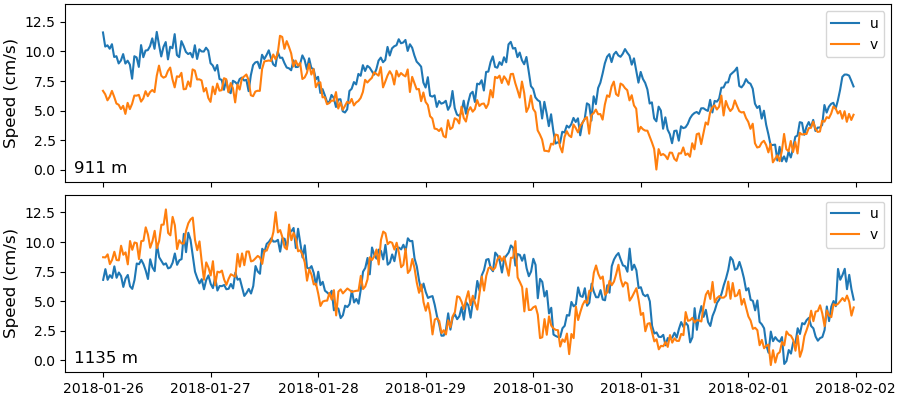

In [51]:
fig, axes = plt.subplots(nrows=2,ncols=1,constrained_layout=True,figsize=(9,4),sharex=True)

time_range = slice('2018-01-26','2018-02-01')

axes[0].plot(D_vel_mid.sel(time=time_range).time,D_vel_mid.sel(time=time_range).u,label='u')
axes[0].plot(D_vel_mid.sel(time=time_range).time,D_vel_mid.sel(time=time_range).v,label='v')
axes[0].legend()
axes[0].set_ylim(-1,14)
axes[0].set_ylabel('Speed (cm/s)')
axes[0].text(0.01, 0.05, '911 m', transform=axes[0].transAxes)

axes[1].plot(D_vel_bot.sel(time=time_range).time,D_vel_bot.sel(time=time_range).u,label='u')
axes[1].plot(D_vel_bot.sel(time=time_range).time,D_vel_bot.sel(time=time_range).v,label='v')
axes[1].legend()
axes[1].set_ylim(-1,14)
axes[1].set_ylabel('Speed (cm/s)')
axes[1].text(0.01, 0.05, '1135 m', transform=axes[1].transAxes)

# plt.savefig('D_reference_vel.png',dpi=400,bbox_inches='tight')